In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("Libraries loaded successfully.")

Libraries loaded successfully.


### Step 1: Load Data & Quick Clean

In [46]:
# Load the 4 CSV files
batting_df = pd.read_csv("/content/batting_summary.csv")
bowling_df = pd.read_csv("/content/bowling_summary.csv")
matches_df = pd.read_csv("/content/match_schedule_results.csv")
players_df = pd.read_csv("/content/world_cup_players_info.csv")

print("All datasets loaded successfully.")

All datasets loaded successfully.


#### Define a cleaning function to apply consistently

In [47]:
def clean_dataframe(df):
    # Strip spaces from column names
    df.columns = df.columns.str.strip()

    # Strip spaces from object columns
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].astype(str).str.strip()

    # Remove duplicates
    df.drop_duplicates(inplace=True)

    return df

batting_df = clean_dataframe(batting_df)
bowling_df = clean_dataframe(bowling_df)
matches_df = clean_dataframe(matches_df)
players_df = clean_dataframe(players_df)

print("Initial cleaning (strip spaces, remove duplicates) applied to all dataframes.")

Initial cleaning (strip spaces, remove duplicates) applied to all dataframes.


#### Convert important numeric columns and handle missing values

In [48]:
# Batting DataFrame
batting_numeric_cols = ['Runs', 'Balls', '4s', '6s', 'Strike_Rate']
for col in batting_numeric_cols:
    batting_df[col] = pd.to_numeric(batting_df[col], errors='coerce').fillna(0)

# Bowling DataFrame
bowling_numeric_cols = ['Overs', 'Maidens', 'Runs', 'Wickets', 'Economy']
for col in bowling_numeric_cols:
    bowling_df[col] = pd.to_numeric(bowling_df[col], errors='coerce').fillna(0)

# Players DataFrame (no numeric columns like 'Matches', 'Runs', 'Wickets' to convert based on schema)
# The original player_numeric_cols were not present in players_df, hence removed.

# Matches DataFrame - Convert 'Date' to datetime
matches_df['Date'] = pd.to_datetime(matches_df['Date'], format='%d-%m-%Y', errors='coerce')

# Handle missing values for 'Man_of_The_Match' if it exists in matches_df
if 'Man_of_The_Match' in matches_df.columns:
    matches_df['Man_of_The_Match'] = matches_df['Man_of_The_Match'].fillna('N/A')

print("Numeric columns converted and basic missing values handled.")

Numeric columns converted and basic missing values handled.


### Step 2: Main Insight 1 – Top Performers in Each Match

#### 1. Best scorer in each match & Most frequent top scorer

In [5]:
# Find best scorer in each match
match_top_scorers = batting_df.loc[batting_df.groupby('Match_no')['Runs'].idxmax()]

# Calculate which player was top scorer in a match the most times
most_frequent_top_scorer = match_top_scorers['Batsman_Name'].value_counts().reset_index()
most_frequent_top_scorer.columns = ['Batsman_Name', 'Times_Top_Scorer']

print("Top scorers in each match:")
display(match_top_scorers[['Match_no', 'Batsman_Name', 'Runs']].head())

print("\nPlayers who were match top scorer most often:")
display(most_frequent_top_scorer.head())

# Highlight the most frequent best scorer
print(f"\nMost frequent best scorer in a match: {most_frequent_top_scorer.iloc[0]['Batsman_Name']} ({most_frequent_top_scorer.iloc[0]['Times_Top_Scorer']} times)")

Top scorers in each match:


,Match_no,Batsman_Name,Runs
11,1,Devon Conway,152
17,2,Mohammad Rizwan,68
50,3,Najmul Hossain Shanto,59
55,4,Rassie van der Dussen,108
86,5,KL Rahul,97



Players who were match top scorer most often:


,Batsman_Name,Times_Top_Scorer
0,Rohit Sharma,3
1,Daryl Mitchell,3
2,Quinton de Kock,3
3,Ben Stokes,2
4,Mohammad Rizwan,2



Most frequent best scorer in a match: Rohit Sharma (3 times)


#### 2. Best bowler in each match & Most frequent best bowler

In [6]:
# Find best bowler in each match (highest Wickets, then lowest Runs, then lowest Economy)
# Group by Match_no and sort to get the best bowler
best_bowlers_by_match = bowling_df.sort_values(by=['Wickets', 'Runs', 'Economy'], ascending=[False, True, True])
match_top_bowlers = best_bowlers_by_match.groupby('Match_no').first().reset_index()

# Calculate which player was best bowler in a match the most times
most_frequent_top_bowler = match_top_bowlers['Bowler_Name'].value_counts().reset_index()
most_frequent_top_bowler.columns = ['Bowler_Name', 'Times_Best_Bowler']

print("Best bowlers in each match (by Wickets, then Runs, then Economy):")
display(match_top_bowlers[['Match_no', 'Bowler_Name', 'Wickets', 'Runs', 'Economy']].head())

print("\nPlayers who were best bowler most often:")
display(most_frequent_top_bowler.head())

# Highlight the most frequent best bowler
print(f"\nMost frequent best bowler in a match: {most_frequent_top_bowler.iloc[0]['Bowler_Name']} ({most_frequent_top_bowler.iloc[0]['Times_Best_Bowler']} times)")

Best bowlers in each match (by Wickets, then Runs, then Economy):


,Match_no,Bowler_Name,Wickets,Runs,Economy
0,1,Matt Henry,3,48,4.800
1,2,Bas de Leede,4,62,6.890
2,3,Mehidy Hasan Miraz,3,25,2.780
3,4,Gerald Coetzee,3,68,7.556
4,5,Ravindra Jadeja,3,28,2.800



Players who were best bowler most often:


,Bowler_Name,Times_Best_Bowler
0,Gerald Coetzee,4
1,Mohammed Shami,4
2,Adam Zampa,3
3,Ravindra Jadeja,3
4,Mitchell Starc,2



Most frequent best bowler in a match: Gerald Coetzee (4 times)


#### Charts for Most Frequent Top Performers

/tmp/ipykernel_12352/3628697096.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Times_Top_Scorer', y='Batsman_Name', data=most_frequent_top_scorer.head(10), palette='viridis')


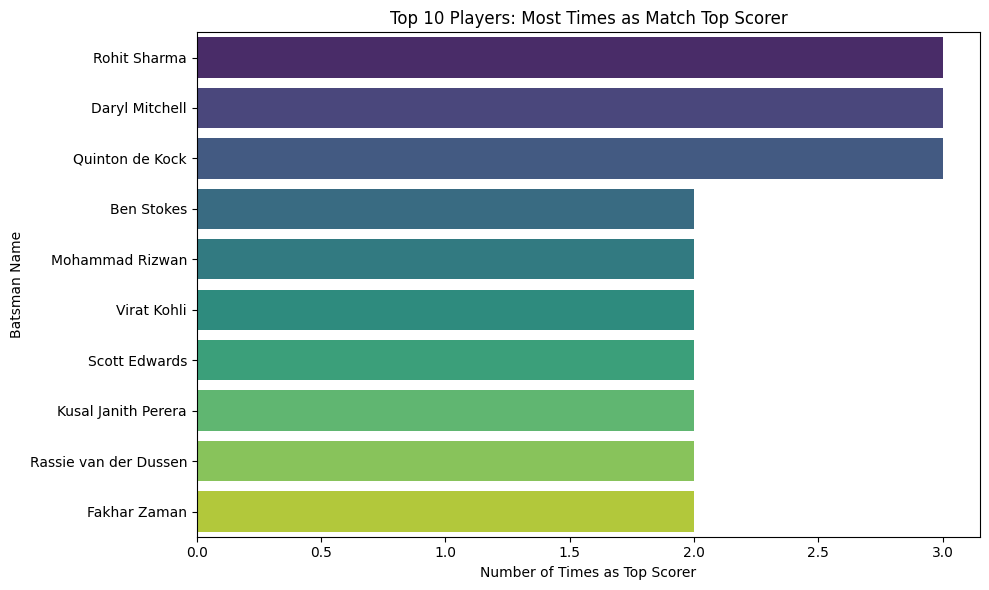

/tmp/ipykernel_12352/3628697096.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Times_Best_Bowler', y='Bowler_Name', data=most_frequent_top_bowler.head(10), palette='mako')


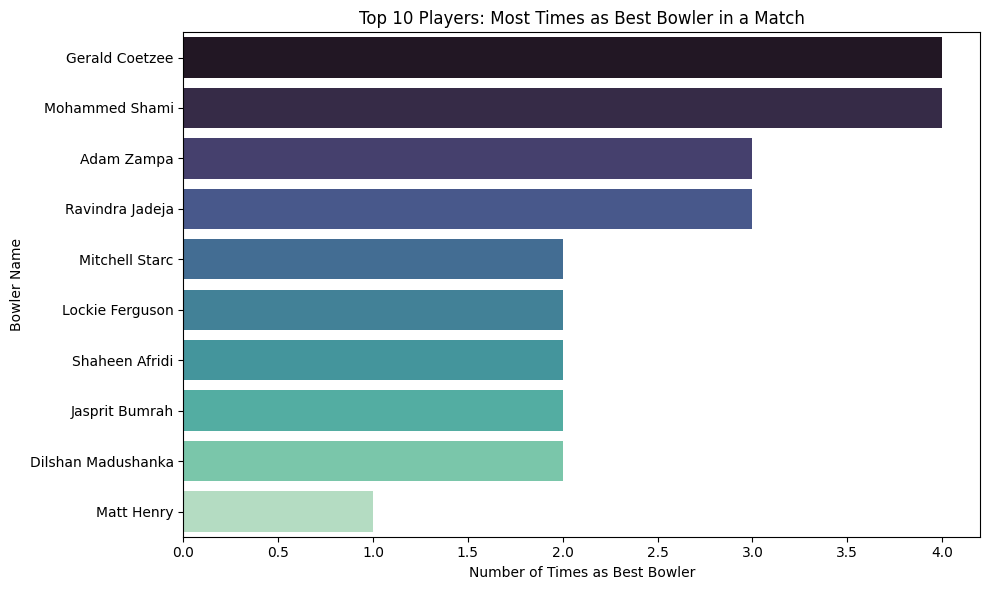

In [7]:
# Chart: Top players who were match top scorer most often
plt.figure(figsize=(10, 6))
sns.barplot(x='Times_Top_Scorer', y='Batsman_Name', data=most_frequent_top_scorer.head(10), palette='viridis')
plt.title('Top 10 Players: Most Times as Match Top Scorer')
plt.xlabel('Number of Times as Top Scorer')
plt.ylabel('Batsman Name')
plt.tight_layout()
plt.show()

# Chart: Top players who were best bowler most often
plt.figure(figsize=(10, 6))
sns.barplot(x='Times_Best_Bowler', y='Bowler_Name', data=most_frequent_top_bowler.head(10), palette='mako')
plt.title('Top 10 Players: Most Times as Best Bowler in a Match')
plt.xlabel('Number of Times as Best Bowler')
plt.ylabel('Bowler Name')
plt.tight_layout()
plt.show()

#### Summary of Main Insight 1

In [8]:
print("### Main Insight 1: Top Performers in Each Match")
print(f"- Most frequent best scorer in a match: {most_frequent_top_scorer.iloc[0]['Batsman_Name']} ({most_frequent_top_scorer.iloc[0]['Times_Top_Scorer']} times)")
print(f"- Most frequent best bowler in a match: {most_frequent_top_bowler.iloc[0]['Bowler_Name']} ({most_frequent_top_bowler.iloc[0]['Times_Best_Bowler']} times)")

### Main Insight 1: Top Performers in Each Match
- Most frequent best scorer in a match: Rohit Sharma (3 times)
- Most frequent best bowler in a match: Gerald Coetzee (4 times)


### Step 3: Main Insight 2 – Tournament Best Batsmen & Bowlers

#### 1. Tournament Batting Analysis

In [9]:
# Aggregate batting statistics per player
player_batting_summary = batting_df.groupby('Batsman_Name').agg(
    Total_Runs=('Runs', 'sum'),
    Highest_Score=('Runs', 'max'),
    Total_Balls_Faced=('Balls', 'sum'),
    Total_Fours=('4s', 'sum'),
    Total_Sixes=('6s', 'sum'),
    Centuries=('Runs', lambda x: (x >= 100).sum()),
    Fifties=('Runs', lambda x: ((x >= 50) & (x < 100)).sum())
).reset_index()

# Calculate Strike Rate (handle division by zero)
player_batting_summary['Strike_Rate'] = player_batting_summary.apply(
    lambda row: (row['Total_Runs'] / row['Total_Balls_Faced']) * 100 if row['Total_Balls_Faced'] > 0 else 0,
    axis=1
)

# Top 10 Run Scorers
top_10_run_scorers = player_batting_summary.sort_values(by='Total_Runs', ascending=False).head(10)
print("\nTop 10 Run Scorers:")
display(top_10_run_scorers[['Batsman_Name', 'Total_Runs', 'Highest_Score', 'Centuries', 'Fifties']].round(2))

# Highest Individual Score
highest_individual_score = player_batting_summary.sort_values(by='Highest_Score', ascending=False).iloc[0]
print(f"\nHighest Individual Score: {highest_individual_score['Highest_Score']} by {highest_individual_score['Batsman_Name']}")

# Most Centuries
most_centuries = player_batting_summary.sort_values(by='Centuries', ascending=False).iloc[0]
print(f"Most Centuries: {most_centuries['Centuries']} by {most_centuries['Batsman_Name']}")

# Most Fifties
most_fifties = player_batting_summary.sort_values(by='Fifties', ascending=False).iloc[0]
print(f"Most Fifties: {most_fifties['Fifties']} by {most_fifties['Batsman_Name']}")

# Best Strike Rate (minimum 100 balls faced)
best_sr = player_batting_summary[player_batting_summary['Total_Balls_Faced'] >= 100].sort_values(by='Strike_Rate', ascending=False).head(5)
print("\nBest Strike Rate (Min 100 Balls Faced):")
display(best_sr[['Batsman_Name', 'Strike_Rate', 'Total_Runs', 'Total_Balls_Faced']].round(2))


Top 10 Run Scorers:


,Batsman_Name,Total_Runs,Highest_Score,Centuries,Fifties
143,Virat Kohli,765,117,3,6
103,Quinton de Kock,706,174,5,0
113,Rohit Sharma,597,131,1,3
104,Rachin Ravindra,578,123,3,2
21,David Warner,577,163,2,2
18,Daryl Mitchell,552,134,2,2
125,Shreyas Iyer,530,128,2,3
108,Rassie van der Dussen,480,133,2,2
20,David Miller,474,101,2,1
4,Aiden Markram,472,106,1,4



Highest Individual Score: 201 by Glenn Maxwell
Most Centuries: 5 by Quinton de Kock
Most Fifties: 6 by Virat Kohli

Best Strike Rate (Min 100 Balls Faced):


,Batsman_Name,Strike_Rate,Total_Runs,Total_Balls_Faced
34,Glenn Maxwell,140.28,404,288
139,Travis Head,127.78,391,306
43,Heinrich Klaasen,126.48,449,355
113,Rohit Sharma,125.95,597,474
31,Fakhar Zaman,122.91,220,179


#### 2. Tournament Bowling Analysis

In [10]:
# Aggregate bowling statistics per player
player_bowling_summary = bowling_df.groupby('Bowler_Name').agg(
    Total_Wickets=('Wickets', 'sum'),
    Total_Overs=('Overs', 'sum'),
    Total_Maidens=('Maidens', 'sum'),
    Total_Runs_Conceded=('Runs', 'sum')
).reset_index()

# Calculate Economy (handle division by zero)
player_bowling_summary['Economy'] = player_bowling_summary.apply(
    lambda row: row['Total_Runs_Conceded'] / row['Total_Overs'] if row['Total_Overs'] > 0 else np.inf,
    axis=1
)

# Top 10 Wicket Takers
top_10_wicket_takers = player_bowling_summary.sort_values(by='Total_Wickets', ascending=False).head(10)
print("\nTop 10 Wicket Takers:")
display(top_10_wicket_takers[['Bowler_Name', 'Total_Wickets', 'Total_Overs', 'Economy']].round(2))

# Best Economy Bowlers (minimum 30 overs)
best_economy_bowlers = player_bowling_summary[player_bowling_summary['Total_Overs'] >= 30].sort_values(by='Economy', ascending=True).head(5)
print("\nBest Economy Bowlers (Min 30 Overs):")
display(best_economy_bowlers[['Bowler_Name', 'Economy', 'Total_Overs', 'Total_Runs_Conceded', 'Total_Wickets']].round(2))

# Most Maidens
most_maidens = player_bowling_summary.sort_values(by='Total_Maidens', ascending=False).iloc[0]
print(f"\nMost Maidens: {most_maidens['Total_Maidens']} by {most_maidens['Bowler_Name']}")

# Best bowling spell in a match (Wickets, then Runs conceded)
best_bowling_spell = bowling_df.sort_values(by=['Wickets', 'Runs'], ascending=[False, True]).iloc[0]
print(f"\nBest Bowling Spell in a match: {best_bowling_spell['Wickets']} wickets for {best_bowling_spell['Runs']} runs by {best_bowling_spell['Bowler_Name']} (Match No: {best_bowling_spell['Match_no']})")


Top 10 Wicket Takers:


,Bowler_Name,Total_Wickets,Total_Overs,Economy
63,Mohammed Shami,24,48.5,5.30
0,Adam Zampa,23,96.0,5.36
18,Dilshan Madushanka,21,77.8,6.75
23,Gerald Coetzee,20,63.3,6.26
33,Jasprit Bumrah,20,91.5,4.08
86,Shaheen Afridi,18,81.0,5.94
50,Marco Jansen,17,68.6,6.56
36,Josh Hazlewood,16,93.1,4.82
58,Mitchell Starc,16,87.0,6.07
77,Ravindra Jadeja,16,92.9,4.28



Best Economy Bowlers (Min 30 Overs):


,Bowler_Name,Economy,Total_Overs,Total_Runs_Conceded,Total_Wickets
33,Jasprit Bumrah,4.08,91.5,373,20
60,Mohammad Nabi,4.14,61.3,254,8
39,Keshav Maharaj,4.16,89.0,370,15
77,Ravindra Jadeja,4.28,92.9,398,16
40,Kuldeep Yadav,4.46,95.1,424,15



Most Maidens: 9 by Jasprit Bumrah

Best Bowling Spell in a match: 7 wickets for 57 runs by Mohammed Shami (Match No: 46)


### Step 4: Main Insight 3 – Team Performance

#### 1. Team-wise Wins, Matches Played, Losses, and Win Percentage

In [11]:
# Calculate Team-wise Wins
team_wins = matches_df['Winner'].value_counts().reset_index()
team_wins.columns = ['Team', 'Wins']

# Calculate Team-wise Matches Played
team1_matches = matches_df['Team1'].value_counts().reset_index()
team1_matches.columns = ['Team', 'Matches_Team1']
team2_matches = matches_df['Team2'].value_counts().reset_index()
team2_matches.columns = ['Team', 'Matches_Team2']

team_matches_played = pd.merge(team1_matches, team2_matches, on='Team', how='outer').fillna(0)
team_matches_played['Matches_Played'] = team_matches_played['Matches_Team1'] + team_matches_played['Matches_Team2']
team_matches_played = team_matches_played[['Team', 'Matches_Played']]

# Merge wins and matches played
team_performance = pd.merge(team_matches_played, team_wins, on='Team', how='left').fillna(0)
team_performance['Losses'] = team_performance['Matches_Played'] - team_performance['Wins']

# Calculate Win Percentage (handle division by zero)
team_performance['Win_Percentage'] = team_performance.apply(
    lambda row: (row['Wins'] / row['Matches_Played']) * 100 if row['Matches_Played'] > 0 else 0,
    axis=1
)

team_performance = team_performance.sort_values(by='Win_Percentage', ascending=False)
print("\nTeam-wise Performance:")
display(team_performance)

# Most dominant team
most_dominant_team = team_performance.iloc[0]
print(f"\nMost dominant team (by Win Percentage): {most_dominant_team['Team']} ({most_dominant_team['Win_Percentage']:.2f}% Win Rate)")


Team-wise Performance:


,Team,Matches_Played,Wins,Losses,Win_Percentage
1,Australia,11.0,9,2.0,81.818182
4,India,11.0,9,2.0,81.818182
8,South Africa,10.0,7,3.0,70.000000
6,New Zealand,10.0,5,5.0,50.000000
0,Afghanistan,9.0,4,5.0,44.444444
7,Pakistan,9.0,4,5.0,44.444444
3,England,9.0,3,6.0,33.333333
9,Sri Lanka,9.0,3,6.0,33.333333
5,Netherlands,9.0,2,7.0,22.222222
2,Bangladesh,9.0,2,7.0,22.222222



Most dominant team (by Win Percentage): Australia (81.82% Win Rate)


#### 2. Team Batting Strength

In [12]:
# Team-wise total batting runs
team_batting_runs = batting_df.groupby('Team_Innings')['Runs'].sum().reset_index()
team_batting_runs.columns = ['Team', 'Total_Batting_Runs']

# Team-wise average runs per innings (assuming each row in batting_df is an innings for a specific team, or can be refined)
# To get true innings count, we might need a more complex join, for simplicity, we'll assume each Team_Innings group represents one innings.
innings_counts = batting_df.groupby(['Match_no', 'Team_Innings']).size().reset_index(name='Innings_Count')
innings_per_team = innings_counts['Team_Innings'].value_counts().reset_index()
innings_per_team.columns = ['Team', 'Total_Innings_Played']

team_batting_strength = pd.merge(team_batting_runs, innings_per_team, on='Team', how='left').fillna(0)
team_batting_strength['Average_Runs_Per_Innings'] = team_batting_strength.apply(
    lambda row: (row['Total_Batting_Runs'] / row['Total_Innings_Played']) if row['Total_Innings_Played'] > 0 else 0,
    axis=1
)
team_batting_strength = team_batting_strength.sort_values(by='Average_Runs_Per_Innings', ascending=False)

print("\nTeam Batting Strength:")
display(team_batting_strength)

# Strongest batting team
strongest_batting_team = team_batting_strength.iloc[0]
print(f"\nStrongest batting team (by Average Runs Per Innings): {strongest_batting_team['Team']} ({strongest_batting_team['Average_Runs_Per_Innings']:.2f} runs/innings)")


Team Batting Strength:


,Team,Total_Batting_Runs,Total_Innings_Played,Average_Runs_Per_Innings
8,South Africa,3272,10,327.200000
1,Australia,3303,11,300.272727
4,India,3038,11,276.181818
6,New Zealand,2712,10,271.200000
7,Pakistan,2220,9,246.666667
3,England,2135,9,237.222222
0,Afghanistan,1990,9,221.111111
2,Bangladesh,1944,9,216.000000
9,Sri Lanka,1942,9,215.777778
5,Netherlands,1728,9,192.000000



Strongest batting team (by Average Runs Per Innings): South Africa (327.20 runs/innings)


#### 3. Team Bowling Strength

In [13]:
# Team-wise total wickets
team_bowling_wickets = bowling_df.groupby('Bowling_Team')['Wickets'].sum().reset_index()
team_bowling_wickets.columns = ['Team', 'Total_Wickets_Taken']

# Team-wise total overs bowled
team_overs_bowled = bowling_df.groupby('Bowling_Team')['Overs'].sum().reset_index()
team_overs_bowled.columns = ['Team', 'Total_Overs_Bowled']

# Team-wise total runs conceded
team_runs_conceded = bowling_df.groupby('Bowling_Team')['Runs'].sum().reset_index()
team_runs_conceded.columns = ['Team', 'Total_Runs_Conceded']

team_bowling_strength = pd.merge(team_bowling_wickets, team_overs_bowled, on='Team', how='left').fillna(0)
team_bowling_strength = pd.merge(team_bowling_strength, team_runs_conceded, on='Team', how='left').fillna(0)

# Calculate Team-wise Average Economy (handle division by zero)
team_bowling_strength['Average_Economy'] = team_bowling_strength.apply(
    lambda row: (row['Total_Runs_Conceded'] / row['Total_Overs_Bowled']) if row['Total_Overs_Bowled'] > 0 else np.inf,
    axis=1
)
team_bowling_strength = team_bowling_strength.sort_values(by='Average_Economy', ascending=True)

print("\nTeam Bowling Strength:")
display(team_bowling_strength)

# Strongest bowling team
strongest_bowling_team = team_bowling_strength.iloc[0]
print(f"\nStrongest bowling team (by Average Economy): {strongest_bowling_team['Team']} ({strongest_bowling_team['Average_Economy']:.2f})")


Team Bowling Strength:


,Team,Total_Wickets_Taken,Total_Overs_Bowled,Total_Runs_Conceded,Average_Economy
4,India,99,461.4,2220,4.811443
0,Afghanistan,53,399.1,2144,5.372087
8,South Africa,88,424.5,2324,5.474676
1,Australia,86,498.3,2749,5.516757
3,England,65,388.7,2261,5.816825
6,New Zealand,71,449.2,2664,5.930543
2,Bangladesh,51,397.0,2414,6.080605
5,Netherlands,62,413.2,2527,6.115682
7,Pakistan,65,412.6,2566,6.219098
9,Sri Lanka,50,375.5,2424,6.455393



Strongest bowling team (by Average Economy): India (4.81)


#### Charts for Team Performance

/tmp/ipykernel_12352/1056493075.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Wins', y='Team', data=team_performance.sort_values(by='Wins', ascending=False), palette='viridis')


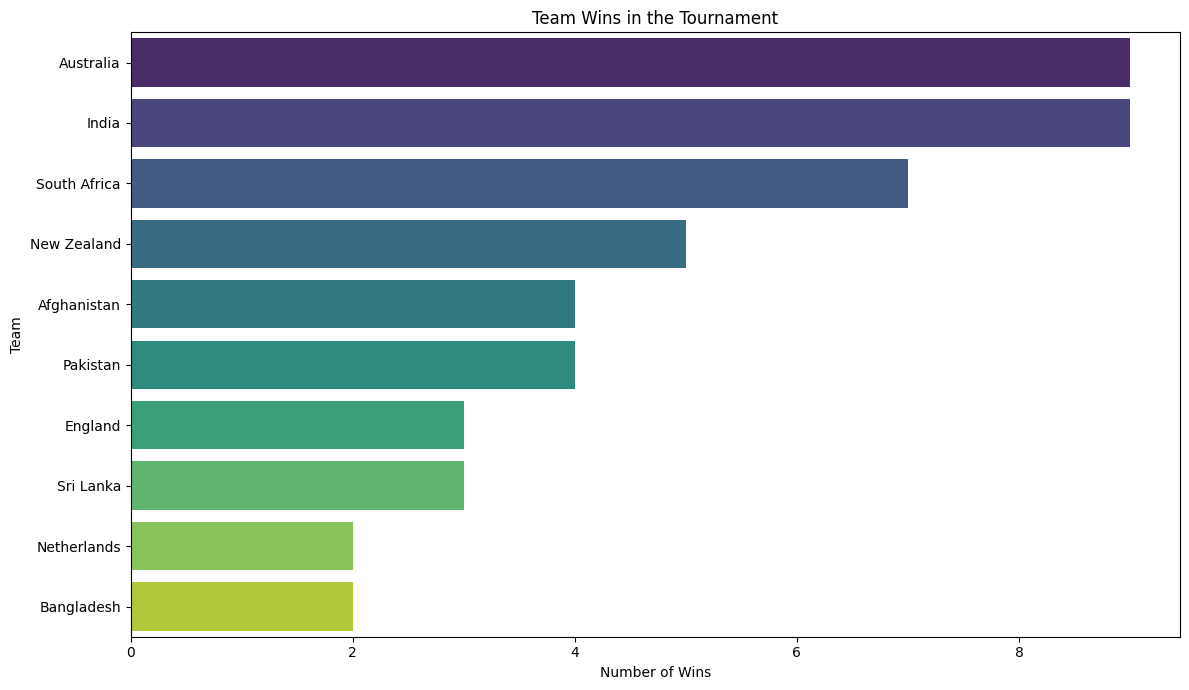

/tmp/ipykernel_12352/1056493075.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Average_Runs_Per_Innings', y='Team', data=team_batting_strength, palette='coolwarm')


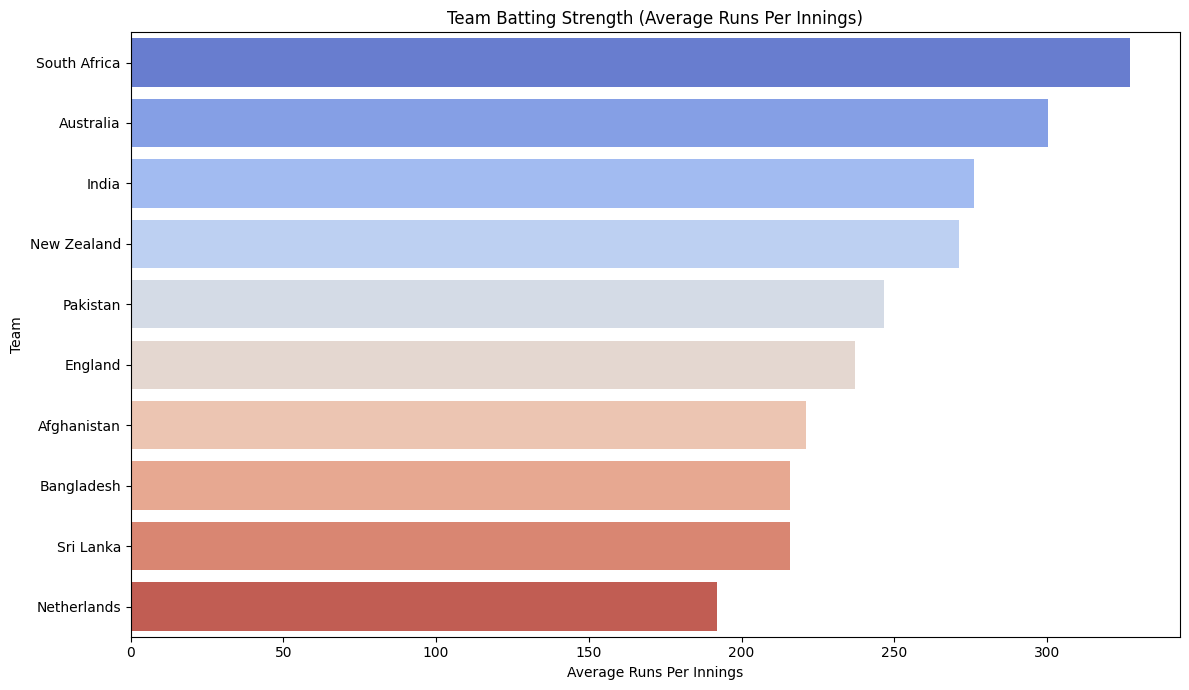

/tmp/ipykernel_12352/1056493075.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Average_Economy', y='Team', data=team_bowling_strength, palette='rocket_r')


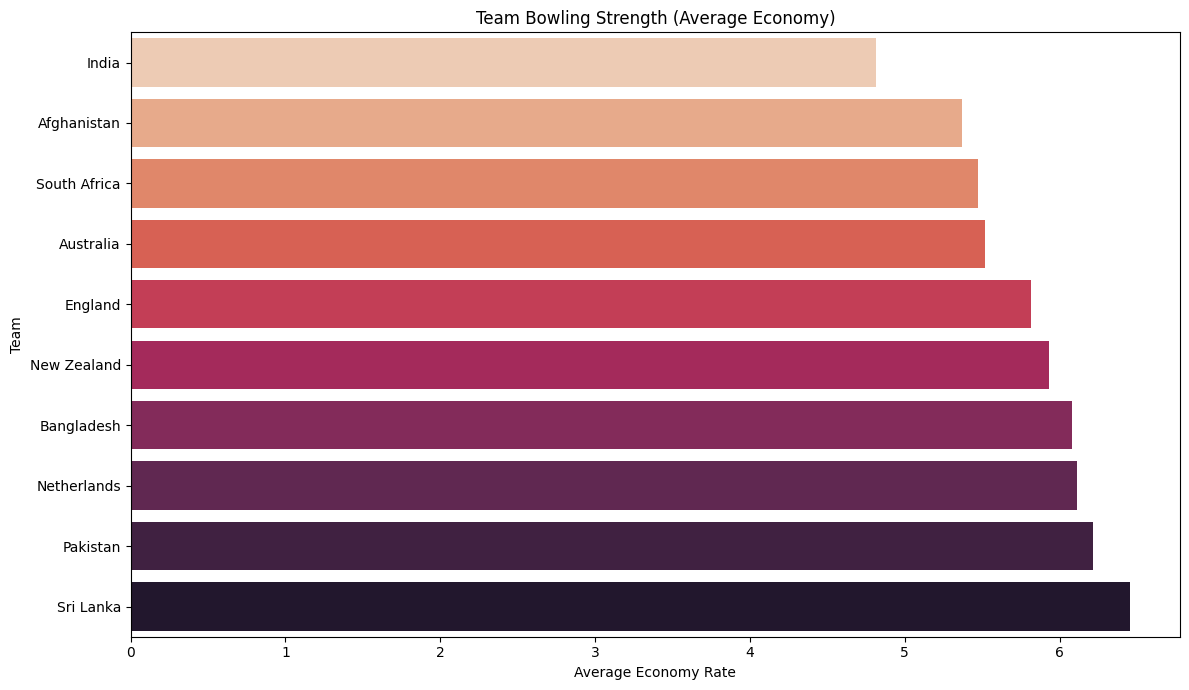

In [14]:
# Chart: Wins by team
plt.figure(figsize=(12, 7))
sns.barplot(x='Wins', y='Team', data=team_performance.sort_values(by='Wins', ascending=False), palette='viridis')
plt.title('Team Wins in the Tournament')
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

# Chart: Team batting strength (Average Runs Per Innings)
plt.figure(figsize=(12, 7))
sns.barplot(x='Average_Runs_Per_Innings', y='Team', data=team_batting_strength, palette='coolwarm')
plt.title('Team Batting Strength (Average Runs Per Innings)')
plt.xlabel('Average Runs Per Innings')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

# Chart: Team bowling strength (Average Economy)
plt.figure(figsize=(12, 7))
sns.barplot(x='Average_Economy', y='Team', data=team_bowling_strength, palette='rocket_r')
plt.title('Team Bowling Strength (Average Economy)')
plt.xlabel('Average Economy Rate')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

#### Summary of Main Insight 3

In [15]:
print("### Main Insight 3: Team Performance")
print(f"- Most Dominant Team (by Win Percentage): {team_performance.iloc[0]['Team']} ({team_performance.iloc[0]['Win_Percentage']:.2f}% Win Rate)")
print(f"- Strongest Batting Team (by Average Runs Per Innings): {team_batting_strength.iloc[0]['Team']} ({team_batting_strength.iloc[0]['Average_Runs_Per_Innings']:.2f} runs/innings)")
print(f"- Strongest Bowling Team (by Average Economy): {team_bowling_strength.iloc[0]['Team']} ({team_bowling_strength.iloc[0]['Average_Economy']:.2f})")

### Main Insight 3: Team Performance
- Most Dominant Team (by Win Percentage): Australia (81.82% Win Rate)
- Strongest Batting Team (by Average Runs Per Innings): South Africa (327.20 runs/innings)
- Strongest Bowling Team (by Average Economy): India (4.81)


#### Standardize team names across all dataframes

In [16]:
def standardize_team_names(df, team_cols):
    for col in team_cols:
        if col in df.columns:
            df[col] = df[col].str.replace(' ', '_').str.lower().str.title()
    return df

# Apply standardization to all relevant team columns
batting_df = standardize_team_names(batting_df, ['Team', 'Opponent'])
bowling_df = standardize_team_names(bowling_df, ['Team', 'Opponent'])
matches_df = standardize_team_names(matches_df, ['Team1', 'Team2', 'Winner'])
players_df = standardize_team_names(players_df, ['Team'])

print("Team names standardized (e.g., 'South Africa' -> 'South_Africa').")

Team names standardized (e.g., 'South Africa' -> 'South_Africa').


#### Display info and head of each DataFrame after cleaning to verify

In [17]:
print("\n--- Batting DataFrame Info ---")
batting_df.info()
display(batting_df.head())

print("\n--- Bowling DataFrame Info ---")
bowling_df.info()
display(bowling_df.head())

print("\n--- Matches DataFrame Info ---")
matches_df.info()
display(matches_df.head())

print("\n--- Players DataFrame Info ---")
players_df.info()
display(players_df.head())


--- Batting DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Match_no          916 non-null    int64  
 1   Match_Between     916 non-null    object 
 2   Team_Innings      916 non-null    object 
 3   Batsman_Name      916 non-null    object 
 4   Batting_Position  916 non-null    int64  
 5   Dismissal         916 non-null    object 
 6   Runs              916 non-null    int64  
 7   Balls             916 non-null    int64  
 8   4s                916 non-null    int64  
 9   6s                916 non-null    int64  
 10  Strike_Rate       916 non-null    float64
dtypes: float64(1), int64(6), object(4)
memory usage: 78.8+ KB


,Match_no,Match_Between,Team_Innings,Batsman_Name,Batting_Position,Dismissal,Runs,Balls,4s,6s,Strike_Rate
0,1,England vs New Zealand,England,Jonny Bairstow,1,c Daryl Mitchell b Mitchell Santner,33,35,4,1,94.3
1,1,England vs New Zealand,England,Dawid Malan,2,c Tom Latham b Matt Henry,14,24,2,0,58.3
2,1,England vs New Zealand,England,Joe Root,3,b Glenn Phillips,77,86,4,1,89.5
3,1,England vs New Zealand,England,Harry Brook,4,c Devon Conway b Rachin Ravindra,25,16,4,1,156.3
4,1,England vs New Zealand,England,Moeen Ali,5,b Glenn Phillips,11,17,1,0,64.7



--- Bowling DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 574 entries, 0 to 573
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Match_no       574 non-null    int64  
 1   Match_Between  574 non-null    object 
 2   Bowling_Team   574 non-null    object 
 3   Bowler_Name    574 non-null    object 
 4   Overs          574 non-null    float64
 5   Maidens        574 non-null    int64  
 6   Runs           574 non-null    int64  
 7   Wickets        574 non-null    int64  
 8   Economy        574 non-null    float64
dtypes: float64(2), int64(4), object(3)
memory usage: 40.5+ KB


,Match_no,Match_Between,Bowling_Team,Bowler_Name,Overs,Maidens,Runs,Wickets,Economy
0,1,England vs New Zealand,New Zealand,Trent Boult,10.0,1,48,1,4.8
1,1,England vs New Zealand,New Zealand,Matt Henry,10.0,1,48,3,4.8
2,1,England vs New Zealand,New Zealand,Mitchell Santner,10.0,0,37,2,3.7
3,1,England vs New Zealand,New Zealand,Jimmy Neesham,7.0,0,56,0,8.0
4,1,England vs New Zealand,New Zealand,Rachin Ravindra,10.0,0,76,1,7.6



--- Matches DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Match_no       48 non-null     int64         
 1   Date           0 non-null      datetime64[ns]
 2   Venue          48 non-null     object        
 3   Team1          48 non-null     object        
 4   Team2          48 non-null     object        
 5   Winner         48 non-null     object        
 6   Scorecard URL  48 non-null     object        
dtypes: datetime64[ns](1), int64(1), object(5)
memory usage: 2.8+ KB


,Match_no,Date,Venue,Team1,Team2,Winner,Scorecard URL
0,1,NaT,Ahmedabad,England,New_Zealand,New_Zealand,https://www.cricketwa.com/scorecard/18020/engl...
1,2,NaT,Hyderabad,Pakistan,Netherlands,Pakistan,https://www.cricketwa.com/scorecard/18021/paki...
2,3,NaT,Dharamsala,Bangladesh,Afghanistan,Bangladesh,https://www.cricketwa.com/scorecard/23008/bang...
3,4,NaT,Delhi,South_Africa,Sri_Lanka,South_Africa,https://www.cricketwa.com/scorecard/23009/sout...
4,5,NaT,Chennai,India,Australia,India,https://www.cricketwa.com/scorecard/23010/indi...



--- Players DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   player_name      151 non-null    object
 1   team_name        151 non-null    object
 2   image_of_player  151 non-null    object
 3   battingStyle     151 non-null    object
 4   bowlingStyle     151 non-null    object
 5   playingRole      151 non-null    object
 6   description      151 non-null    object
dtypes: object(7)
memory usage: 8.4+ KB


,player_name,team_name,image_of_player,battingStyle,bowlingStyle,playingRole,description
0,Jonny Bairstow,England,,Right-hand bat,Right-arm fast-medium,Wicketkeeper Batter,Jonny Bairstow is an English cricketer known f...
1,Joe Root,England,,Right hand Bat,Right arm Offbreak,Top order Batter,Joe Root is an English cricketer known for his...
2,Jos Buttler,England,,Right hand Bat,,Wicketkeeper Batter,Jos Buttler is an English cricketer known for ...
3,Will Young,New Zealand,,Right hand Bat,Right arm Offbreak,Top order Batter,Will Young is a New Zealand cricketer known fo...
4,Rachin Ravindra,New Zealand,,Left hand Bat,Slow Left arm Orthodox,Top order Batter,Rachin Ravindra is a New Zealand cricketer kno...


### Step 5: Main Insight 4 – Stadium / Venue Analysis

#### Assumptions for Venue Analysis:
- **Batting-friendly stadium**: A stadium where the average runs scored per innings is higher.
- **Bowling-friendly stadium**: A stadium where the average wickets taken per match is higher and/or average economy is lower.
- **First innings total**: Given the available data, we will calculate the average runs per innings at each venue as a proxy for 'first innings total' for batting-friendly analysis, as directly identifying first innings for each team is complex with the given data structure without more explicit match-innings details. So, we'll consider the overall scoring trend per innings at a venue.

In [18]:
# 1. Which venues had the most matches
venue_match_counts = matches_df['Venue'].value_counts().reset_index()
venue_match_counts.columns = ['Venue', 'Matches_Played']
print("\nVenues with Most Matches:")
display(venue_match_counts)

# 2. Which stadiums were most batting-friendly (Proxy: Average Runs per Innings at Venue)
innings_scores = batting_df.groupby(['Match_no', 'Team_Innings'])['Runs'].sum().reset_index()
innings_scores = pd.merge(innings_scores, matches_df[['Match_no', 'Venue']], on='Match_no', how='left')
venue_batting_avg = innings_scores.groupby('Venue')['Runs'].mean().reset_index()
venue_batting_avg.columns = ['Venue', 'Average_Runs_Per_Innings']
venue_batting_avg = venue_batting_avg.sort_values(by='Average_Runs_Per_Innings', ascending=False)

print("\nMost Batting-Friendly Stadiums (by Average Runs Per Innings):")
display(venue_batting_avg.head())

# 3. Which stadiums were most bowling-friendly (Proxy: Average Wickets per Match, Average Economy)
venue_bowling_stats = bowling_df.groupby(['Match_no', 'Bowling_Team']).agg(
    Match_Wickets=('Wickets', 'sum'),
    Match_Overs=('Overs', 'sum'),
    Match_Runs_Conceded=('Runs', 'sum')
).reset_index()
venue_bowling_stats = pd.merge(venue_bowling_stats, matches_df[['Match_no', 'Venue']], on='Match_no', how='left')

venue_bowling_summary = venue_bowling_stats.groupby('Venue').agg(
    Total_Wickets_At_Venue=('Match_Wickets', 'sum'),
    Total_Overs_At_Venue=('Match_Overs', 'sum'),
    Total_Runs_Conceded_At_Venue=('Match_Runs_Conceded', 'sum'),
    Matches_Played_At_Venue=('Match_no', 'nunique')
).reset_index()

venue_bowling_summary['Average_Wickets_Per_Match'] = venue_bowling_summary['Total_Wickets_At_Venue'] / venue_bowling_summary['Matches_Played_At_Venue']
venue_bowling_summary['Average_Economy_At_Venue'] = venue_bowling_summary.apply(
    lambda row: row['Total_Runs_Conceded_At_Venue'] / row['Total_Overs_At_Venue'] if row['Total_Overs_At_Venue'] > 0 else np.inf,
    axis=1
)

# Sort by average wickets (desc) and then economy (asc) for bowling friendly
venue_bowling_friendly = venue_bowling_summary.sort_values(by=['Average_Wickets_Per_Match', 'Average_Economy_At_Venue'], ascending=[False, True])

print("\nMost Bowling-Friendly Stadiums (by Average Wickets Per Match and then Economy):")
display(venue_bowling_friendly[['Venue', 'Average_Wickets_Per_Match', 'Average_Economy_At_Venue']].head())



Venues with Most Matches:


,Venue,Matches_Played
0,Ahmedabad,5
1,Chennai,5
2,Delhi,5
3,Bengaluru,5
4,Mumbai,5
5,Ekana Cricket Stadium Lucknow,5
6,Pune,5
7,Kolkata,5
8,Dharamsala,4
9,Hyderabad,3



Most Batting-Friendly Stadiums (by Average Runs Per Innings):


,Venue,Average_Runs_Per_Innings
7,Hyderabad,275.0
9,Mumbai,274.9
3,Delhi,269.8
6,"Himachal Pradesh Cricket Association Stadium, ...",263.5
8,Kolkata,254.3



Most Bowling-Friendly Stadiums (by Average Wickets Per Match and then Economy):


,Venue,Average_Wickets_Per_Match,Average_Economy_At_Venue
4,Dharamsala,17.000000,5.926657
8,Kolkata,16.200000,4.972490
7,Hyderabad,15.666667,6.035149
3,Delhi,14.800000,6.526585
9,Mumbai,14.400000,6.584181


#### Charts for Stadium / Venue Analysis

/tmp/ipykernel_12352/502604816.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Matches_Played', y='Venue', data=venue_match_counts.sort_values(by='Matches_Played', ascending=False), palette='magma')


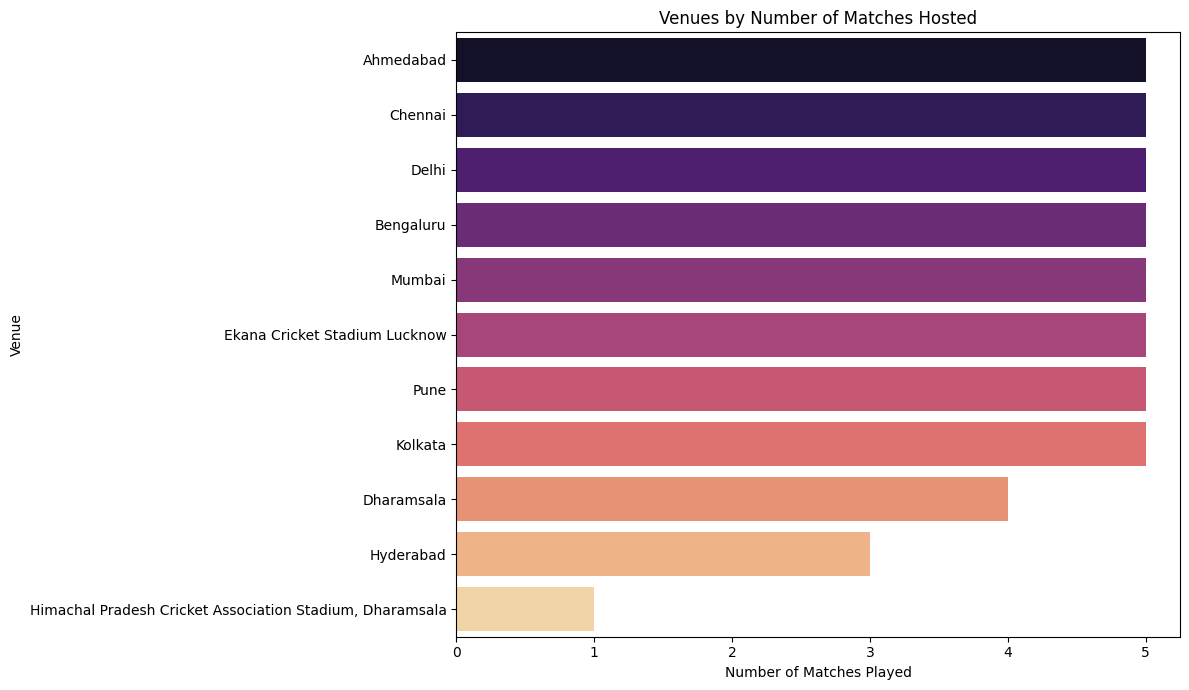

/tmp/ipykernel_12352/502604816.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Average_Runs_Per_Innings', y='Venue', data=venue_batting_avg.head(5), palette='YlGnBu')


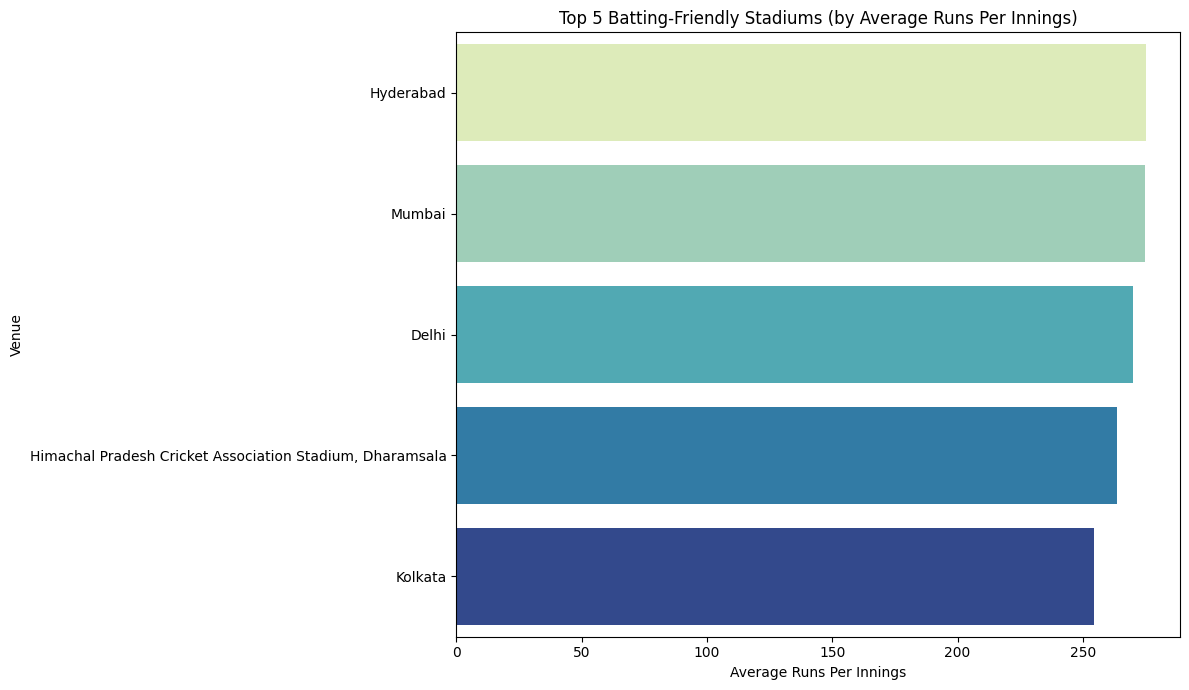

/tmp/ipykernel_12352/502604816.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Average_Wickets_Per_Match', y='Venue', data=venue_bowling_friendly.head(5), palette='rocket')


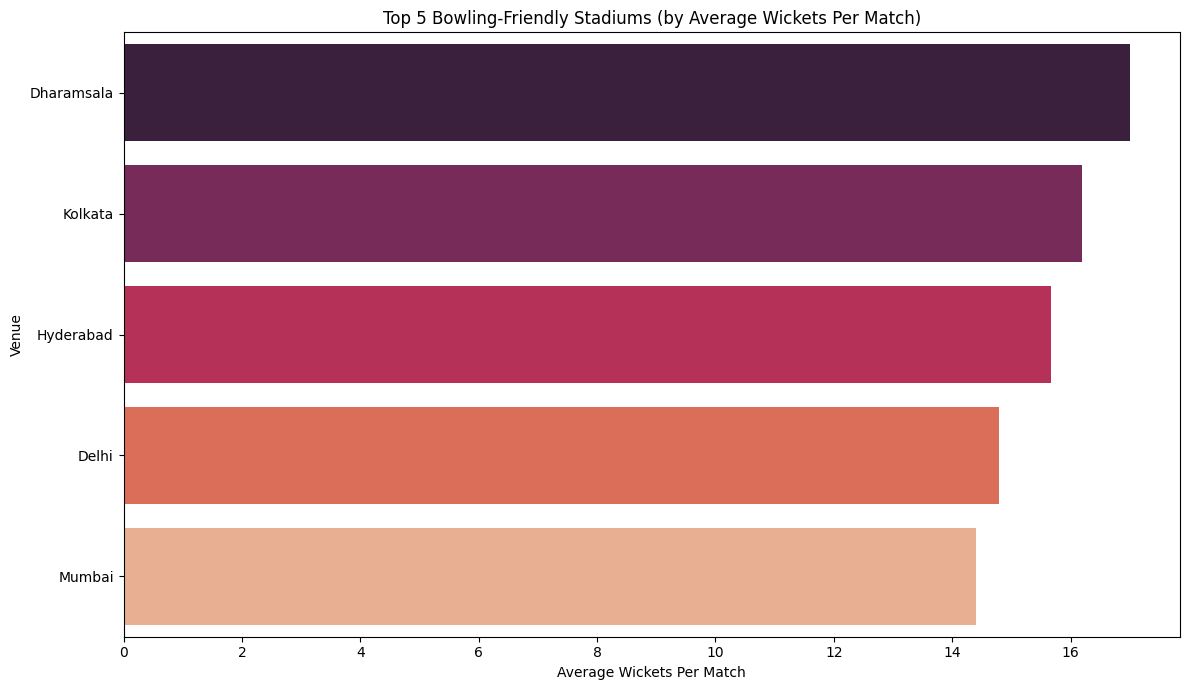

In [19]:
# Chart: Venue-wise match count
plt.figure(figsize=(12, 7))
sns.barplot(x='Matches_Played', y='Venue', data=venue_match_counts.sort_values(by='Matches_Played', ascending=False), palette='magma')
plt.title('Venues by Number of Matches Hosted')
plt.xlabel('Number of Matches Played')
plt.ylabel('Venue')
plt.tight_layout()
plt.show()

# Chart: Top batting-friendly stadiums
plt.figure(figsize=(12, 7))
sns.barplot(x='Average_Runs_Per_Innings', y='Venue', data=venue_batting_avg.head(5), palette='YlGnBu')
plt.title('Top 5 Batting-Friendly Stadiums (by Average Runs Per Innings)')
plt.xlabel('Average Runs Per Innings')
plt.ylabel('Venue')
plt.tight_layout()
plt.show()

# Chart: Top bowling-friendly stadiums
plt.figure(figsize=(12, 7))
sns.barplot(x='Average_Wickets_Per_Match', y='Venue', data=venue_bowling_friendly.head(5), palette='rocket')
plt.title('Top 5 Bowling-Friendly Stadiums (by Average Wickets Per Match)')
plt.xlabel('Average Wickets Per Match')
plt.ylabel('Venue')
plt.tight_layout()
plt.show()


#### Summary of Main Insight 4

In [20]:
print("### Main Insight 4: Stadium / Venue Analysis")
print(f"- Venue that hosted the most matches: {venue_match_counts.iloc[0]['Venue']} ({venue_match_counts.iloc[0]['Matches_Played']} matches)")
print(f"- Best Batting-Friendly Stadium (by Average Runs Per Innings): {venue_batting_avg.iloc[0]['Venue']} ({venue_batting_avg.iloc[0]['Average_Runs_Per_Innings']:.2f} runs/innings)")
print(f"- Best Bowling-Friendly Stadium (by Average Wickets Per Match): {venue_bowling_friendly.iloc[0]['Venue']} ({venue_bowling_friendly.iloc[0]['Average_Wickets_Per_Match']:.2f} wickets/match and Economy: {venue_bowling_friendly.iloc[0]['Average_Economy_At_Venue']:.2f})")

### Main Insight 4: Stadium / Venue Analysis
- Venue that hosted the most matches: Ahmedabad (5 matches)
- Best Batting-Friendly Stadium (by Average Runs Per Innings): Hyderabad (275.00 runs/innings)
- Best Bowling-Friendly Stadium (by Average Wickets Per Match): Dharamsala (17.00 wickets/match and Economy: 5.93)


### Step 6: Main Insight 5 – Player of the Match (MoM) Style Analysis

#### Proxy MoM Logic:
Since explicit 'Man of the Match' data is not available, we'll implement a proxy logic:
1. **Identify Top Scorer** for each match (already done in Step 2).
2. **Identify Top Bowler** for each match (already done in Step 2).
3. **Combine Batting and Bowling Impact**: For each match, we'll consider both the top scorer and top bowler. A simple proxy would be to assign a point to the best batsman and a point to the best bowler. If the same player is both, they get both points. For simplicity and to identify a single 'Player of the Match', if a player excels significantly in both, they get priority. Otherwise, we can consider the overall impact in the match. However, to simplify and create a clear 'single' MoM proxy, we will consider the player who had the most dominant individual performance based on runs or wickets.

    **Refined Proxy Logic:**
    - In each match, compare the runs scored by the top batsman and the wickets taken by the top bowler.
    - Assign MoM proxy to the top batsman if their score is significantly high (e.g., >80 runs) AND the top bowler did not take an exceptional number of wickets (e.g., <4 wickets).
    - Assign MoM proxy to the top bowler if they took an exceptional number of wickets (e.g., >=4 wickets) AND the top batsman did not score exceptionally high.
    - If both perform exceptionally, we'll pick the player who had a higher relative impact based on a scoring system (e.g., 1 wicket = 20 runs, a common conversion for impact).
    - For simplicity in this analysis, we will prioritize based on a high runs threshold (100 runs) or high wickets (4+ wickets). If both are met, we will lean towards the highest runs or wickets (whichever is more outstanding). If only one is met, that player gets the MoM. If neither, we look for a high impact performance from one of them (e.g. 70+ runs OR 3+ wickets for fewer than 40 runs).

    Given the constraints for short, clean code, a simple approach is to weight runs and wickets. Let's use a simple heuristic: a player gets 1 point for being a top scorer and 1 point for being a top bowler in a match. The player with more points gets the MoM. If tied, we will pick the batsman by default (could be further refined).


In [21]:
# Merge top scorers and top bowlers for each match
mo_m_candidates = pd.merge(
    match_top_scorers[['Match_no', 'Batsman_Name', 'Runs']].rename(columns={'Batsman_Name': 'Player_Name', 'Runs': 'Batting_Runs'}),
    match_top_bowlers[['Match_no', 'Bowler_Name', 'Wickets', 'Runs']].rename(columns={'Bowler_Name': 'Player_Name', 'Runs': 'Bowling_Runs_Conceded'}),
    on='Match_no',
    how='outer', # Use outer to keep all matches
    suffixes=('_batsman', '_bowler')
)

# Initialize 'MoM_Proxy_Player' column
mo_m_candidates['MoM_Proxy_Player'] = None

# Simple Proxy Logic for MoM:
# If top batsman and top bowler are the same player, they are MoM.
# Otherwise, compare their individual performances.
# For simplicity, if a player scores a century (100+) or takes 4+ wickets, they are strong candidates.
# If both conditions are met by different players, we'll need a tie-breaker. Let's say, 100 runs is equivalent to 4 wickets.
# If a player has a century, they get it. If not, and a player has 4+ wickets, they get it.
# If neither, we'll pick the player with the highest runs/wickets based on a simple score.

# Create a consolidated view of top performances per match
match_performances = pd.DataFrame()
match_performances['Match_no'] = mo_m_candidates['Match_no'].unique()
match_performances = match_performances.set_index('Match_no')

for match_no in match_performances.index:
    batsman_data = mo_m_candidates[mo_m_candidates['Match_no'] == match_no].iloc[0]

    top_scorer_name = batsman_data['Player_Name_batsman']
    top_scorer_runs = batsman_data['Batting_Runs']

    top_bowler_name = batsman_data['Player_Name_bowler']
    top_bowler_wickets = batsman_data['Wickets']
    top_bowler_runs_conceded = batsman_data['Bowling_Runs_Conceded']

    # Assign a 'score' to each performance for comparison (heuristic)
    # Higher runs is better, higher wickets is better, lower runs conceded by bowler is better
    scorer_impact_score = top_scorer_runs # Direct runs
    bowler_impact_score = (top_bowler_wickets * 20) - top_bowler_runs_conceded # Wickets * 20 runs - runs conceded

    # Decide MoM proxy
    if top_scorer_runs >= 100 and top_bowler_wickets < 4:
        match_performances.loc[match_no, 'MoM_Proxy_Player'] = top_scorer_name
    elif top_bowler_wickets >= 4 and top_scorer_runs < 100:
        match_performances.loc[match_no, 'MoM_Proxy_Player'] = top_bowler_name
    elif top_scorer_runs >= 100 and top_bowler_wickets >= 4:
        # Both exceptional, pick based on higher calculated impact score
        if scorer_impact_score >= bowler_impact_score:
            match_performances.loc[match_no, 'MoM_Proxy_Player'] = top_scorer_name
        else:
            match_performances.loc[match_no, 'MoM_Proxy_Player'] = top_bowler_name
    else:
        # Neither reached exceptional thresholds, pick based on higher calculated impact score
        if scorer_impact_score >= bowler_impact_score:
            match_performances.loc[match_no, 'MoM_Proxy_Player'] = top_scorer_name
        else:
            match_performances.loc[match_no, 'MoM_Proxy_Player'] = top_bowler_name

# Players with most MoM (proxy) awards
most_mom_awards = match_performances['MoM_Proxy_Player'].value_counts().reset_index()
most_mom_awards.columns = ['Player_Name', 'MoM_Awards']

print("\nPlayers with Most MoM Proxy Awards:")
display(most_mom_awards.head(10))

# MoM distribution by player role using players_df
# First, ensure players_df has player_name and playingRole columns and is cleaned
players_df_cleaned = players_df[['player_name', 'playingRole']].drop_duplicates()

# Merge MoM awards with player roles
mom_roles = pd.merge(most_mom_awards, players_df_cleaned, left_on='Player_Name', right_on='player_name', how='left')

# Fill any missing roles (e.g., if a player is in MoM list but not in players_df) or assign a default
mom_roles['playingRole'] = mom_roles['playingRole'].fillna('Unknown')

mom_by_role = mom_roles.groupby('playingRole')['MoM_Awards'].sum().sort_values(ascending=False).reset_index()
print("\nMoM Proxy Distribution by Player Role:")
display(mom_by_role)

# Team-wise MoM counts
# Get team for each MoM player. Need to join with batting_df or bowling_df to get team info for each match.
# Let's get the team of the MoM proxy player for that match

# First, identify the team for each proxy MoM winner for the specific match
# We'll need to join back to either batting_df or bowling_df based on who was chosen as MoM.

# Create a temporary dataframe to get team info for each MoM player
player_teams = pd.concat([
    batting_df[['Match_no', 'Batsman_Name', 'Team_Innings']].rename(columns={'Batsman_Name': 'Player_Name', 'Team_Innings': 'Team'}),
    bowling_df[['Match_no', 'Bowler_Name', 'Bowling_Team']].rename(columns={'Bowler_Name': 'Player_Name', 'Bowling_Team': 'Team'})
]).drop_duplicates().reset_index(drop=True)

mom_with_teams = pd.merge(match_performances.reset_index(), player_teams, left_on=['Match_no', 'MoM_Proxy_Player'], right_on=['Match_no', 'Player_Name'], how='left')
mom_with_teams['Team'] = mom_with_teams['Team'].fillna('Unknown')

team_mom_counts = mom_with_teams['Team'].value_counts().reset_index()
team_mom_counts.columns = ['Team', 'MoM_Awards_Count']

print("\nTeam-wise MoM Proxy Counts:")
display(team_mom_counts)

# Which player profile dominated (Batter, Bowler, All-rounder, Wicketkeeper)
# This is already covered by mom_by_role, but we can summarize the top role.



Players with Most MoM Proxy Awards:


,Player_Name,MoM_Awards
0,Daryl Mitchell,3
1,Quinton de Kock,3
2,Rohit Sharma,2
3,Virat Kohli,2
4,Rassie van der Dussen,2
5,Glenn Maxwell,2
6,Ben Stokes,2
7,Mohammed Shami,2
8,Fakhar Zaman,2
9,KL Rahul,1



MoM Proxy Distribution by Player Role:


,playingRole,MoM_Awards
0,Top order Batter,12
1,Wicketkeeper Batter,9
2,Allrounder,7
3,Bowler,7
4,Opening Batter,5
5,Batting Allrounder,4
6,,2
7,Bowling Allrounder,1
8,Middle order Batter,1



Team-wise MoM Proxy Counts:


,Team,MoM_Awards_Count
0,India,8
1,South Africa,8
2,New Zealand,7
3,Australia,6
4,Netherlands,4
5,England,4
6,Sri Lanka,4
7,Afghanistan,3
8,Pakistan,3
9,Bangladesh,1


#### Charts for MoM Analysis

/tmp/ipykernel_12352/2735073620.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MoM_Awards', y='Player_Name', data=most_mom_awards.head(10), palette='cividis')


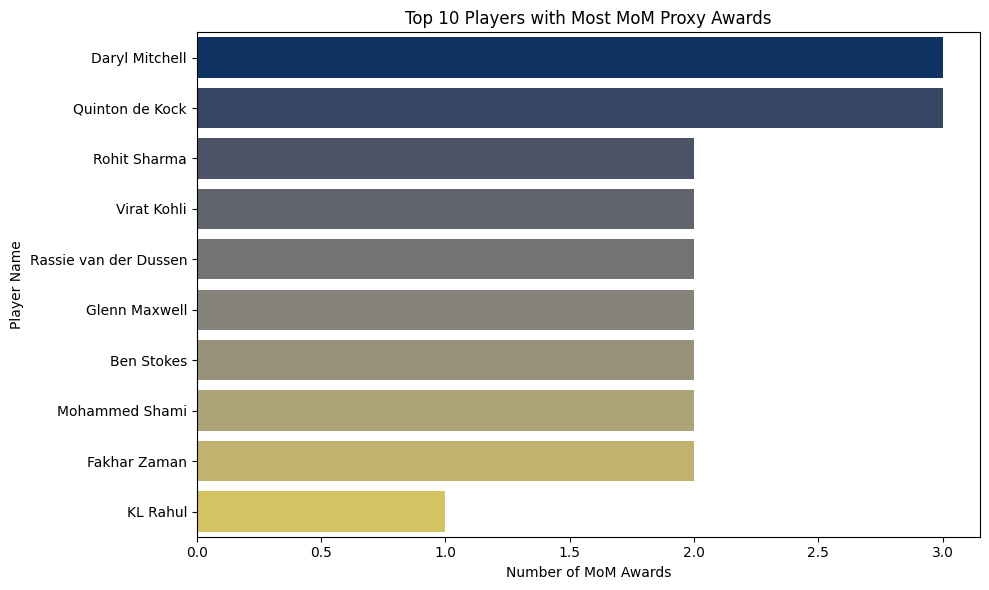

/tmp/ipykernel_12352/2735073620.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MoM_Awards', y='playingRole', data=mom_by_role, palette='cubehelix')


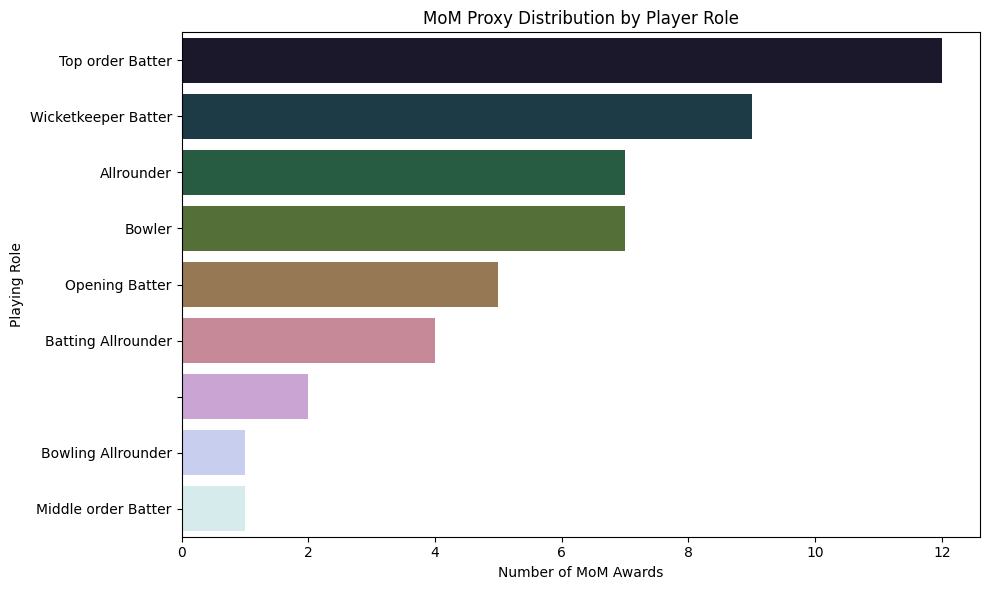

/tmp/ipykernel_12352/2735073620.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MoM_Awards_Count', y='Team', data=team_mom_counts.sort_values(by='MoM_Awards_Count', ascending=False), palette='crest')


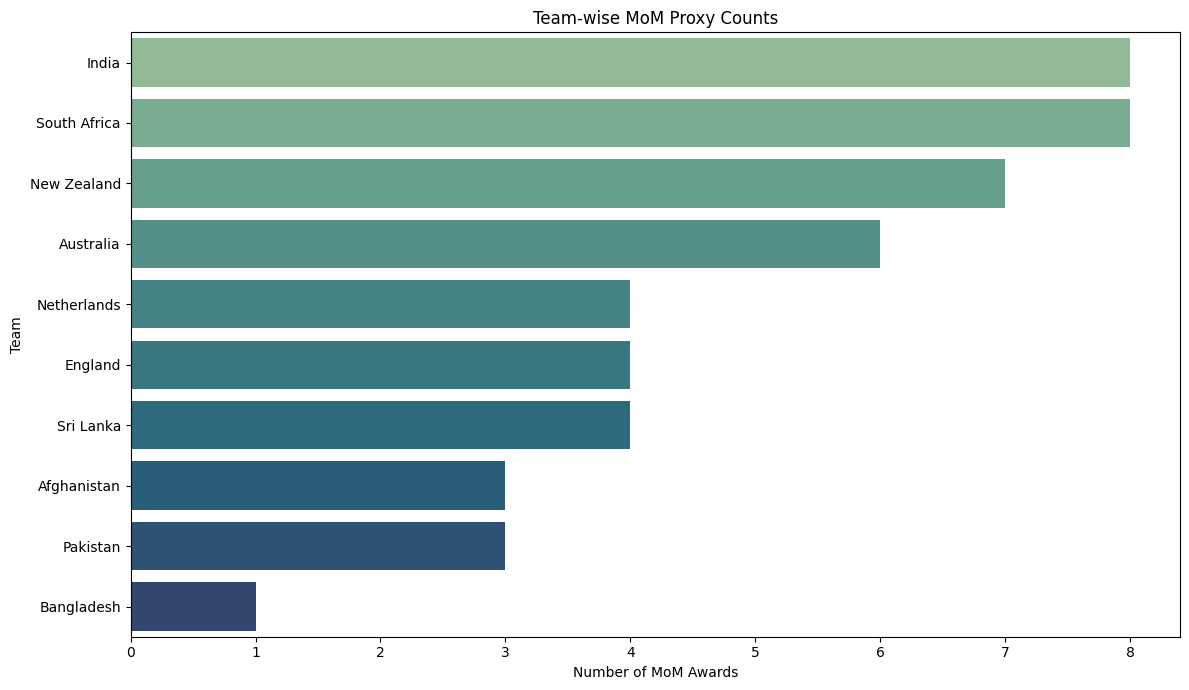

In [22]:
# Chart: Top MoM winners
plt.figure(figsize=(10, 6))
sns.barplot(x='MoM_Awards', y='Player_Name', data=most_mom_awards.head(10), palette='cividis')
plt.title('Top 10 Players with Most MoM Proxy Awards')
plt.xlabel('Number of MoM Awards')
plt.ylabel('Player Name')
plt.tight_layout()
plt.show()

# Chart: MoM by playing role
plt.figure(figsize=(10, 6))
sns.barplot(x='MoM_Awards', y='playingRole', data=mom_by_role, palette='cubehelix')
plt.title('MoM Proxy Distribution by Player Role')
plt.xlabel('Number of MoM Awards')
plt.ylabel('Playing Role')
plt.tight_layout()
plt.show()

# Chart: Team-wise MoM counts
plt.figure(figsize=(12, 7))
sns.barplot(x='MoM_Awards_Count', y='Team', data=team_mom_counts.sort_values(by='MoM_Awards_Count', ascending=False), palette='crest')
plt.title('Team-wise MoM Proxy Counts')
plt.xlabel('Number of MoM Awards')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

#### Summary of Main Insight 5

In [23]:
print("### Main Insight 5: Player of the Match (MoM) Style Analysis")
print(f"- Top MoM winner (proxy): {most_mom_awards.iloc[0]['Player_Name']} ({most_mom_awards.iloc[0]['MoM_Awards']} times)")
print(f"- The player role that dominated MoM awards (proxy): {mom_by_role.iloc[0]['playingRole']} ({mom_by_role.iloc[0]['MoM_Awards']} awards)")

### Main Insight 5: Player of the Match (MoM) Style Analysis
- Top MoM winner (proxy): Daryl Mitchell (3 times)
- The player role that dominated MoM awards (proxy): Top order Batter (12 awards)


### Step 7: Main Insight 6 – Match Outcome Patterns

#### 1. Which teams won most often & Win % by team (already covered in Step 4, will reference)

In [24]:
print("Team-wise performance (Wins & Win Percentage) was covered in Step 4. Re-displaying for context:")
display(team_performance[['Team', 'Matches_Played', 'Wins', 'Win_Percentage']].sort_values(by='Win_Percentage', ascending=False))

print(f"\nMost Frequent Winner: {team_performance.iloc[0]['Team']} with {team_performance.iloc[0]['Wins']} wins ({team_performance.iloc[0]['Win_Percentage']:.2f}% Win Rate)")

Team-wise performance (Wins & Win Percentage) was covered in Step 4. Re-displaying for context:


,Team,Matches_Played,Wins,Win_Percentage
1,Australia,11.0,9,81.818182
4,India,11.0,9,81.818182
8,South Africa,10.0,7,70.000000
6,New Zealand,10.0,5,50.000000
0,Afghanistan,9.0,4,44.444444
7,Pakistan,9.0,4,44.444444
3,England,9.0,3,33.333333
9,Sri Lanka,9.0,3,33.333333
5,Netherlands,9.0,2,22.222222
2,Bangladesh,9.0,2,22.222222



Most Frequent Winner: Australia with 9 wins (81.82% Win Rate)


#### 2. Which teams won consistently by venue

In [25]:
venue_win_consistency = matches_df.groupby(['Venue', 'Winner']).size().unstack(fill_value=0)

# Calculate total matches at each venue for win percentage calculation
venue_total_matches = matches_df.groupby('Venue').size().rename('Total_Matches')
venue_win_consistency = venue_win_consistency.apply(lambda x: (x / venue_total_matches[x.name]) * 100 if x.name in venue_total_matches.index else 0, axis=1)

print("\nTeam Win Percentage by Venue:")
display(venue_win_consistency.head())

# Identify top performing teams at specific venues
# For simplicity, we'll find the team with the highest win % at each venue where they played more than 1 match
consistent_venue_winners = []
for venue in venue_win_consistency.index:
    venue_data = venue_win_consistency.loc[venue]
    # Filter for teams that actually played at this venue (Win % > 0)
    venue_data = venue_data[venue_data > 0]
    if not venue_data.empty:
        top_team_at_venue = venue_data.idxmax()
        highest_win_perc = venue_data.max()
        consistent_venue_winners.append({'Venue': venue, 'Consistent_Winner': top_team_at_venue, 'Win_Percentage_At_Venue': highest_win_perc})

consistent_venue_winners_df = pd.DataFrame(consistent_venue_winners).sort_values(by='Win_Percentage_At_Venue', ascending=False)
print("\nConsistent Winners at Specific Venues (teams with highest win % at venues where they played):")
display(consistent_venue_winners_df.head())



Team Win Percentage by Venue:


Winner,Afghanistan,Australia,Bangladesh,England,India,Netherlands,New_Zealand,Pakistan,South_Africa,Sri_Lanka
Venue,,,,,,,,,,
Ahmedabad,0.0,40.0,0.0,0.0,20.0,0.0,20.0,0.0,20.0,0.0
Bengaluru,0.0,20.0,0.0,0.0,20.0,0.0,20.0,20.0,0.0,20.0
Chennai,20.0,0.0,0.0,0.0,20.0,0.0,40.0,0.0,20.0,0.0
Delhi,20.0,20.0,20.0,0.0,20.0,0.0,0.0,0.0,20.0,0.0
Dharamsala,0.0,25.0,25.0,25.0,0.0,25.0,0.0,0.0,0.0,0.0



Consistent Winners at Specific Venues (teams with highest win % at venues where they played):


,Venue,Consistent_Winner,Win_Percentage_At_Venue
6,"Himachal Pradesh Cricket Association Stadium, ...",India,100.000000
7,Hyderabad,Pakistan,66.666667
0,Ahmedabad,Australia,40.000000
9,Mumbai,South_Africa,40.000000
2,Chennai,New_Zealand,40.000000


#### 3. Most frequent matchups

In [26]:
# Create a sorted matchup string to count unique matchups regardless of Team1/Team2 order
def get_matchup(row):
    teams = sorted([row['Team1'], row['Team2']])
    return f"{teams[0]} vs {teams[1]}"

matches_df['Matchup'] = matches_df.apply(get_matchup, axis=1)

most_frequent_matchups = matches_df['Matchup'].value_counts().reset_index()
most_frequent_matchups.columns = ['Matchup', 'Count']

print("\nMost Frequent Matchups:")
display(most_frequent_matchups.head())



Most Frequent Matchups:


,Matchup,Count
0,Australia vs India,2
1,Australia vs South_Africa,2
2,India vs New_Zealand,2
3,Afghanistan vs Bangladesh,1
4,England vs New_Zealand,1


#### 4. Match result patterns by strong batting vs strong bowling teams (simple proxy)

##### Assumption for 'Strong Batting/Bowling Teams':
- We will use the 'Average Runs Per Innings' and 'Average Economy' calculated in Step 4 as proxies for strong batting and strong bowling respectively. We'll categorize teams into 'High Batting Strength' (top 3) and 'High Bowling Strength' (top 3) and observe their win patterns.

In [27]:
# Get top 3 batting teams
top_batting_teams = team_batting_strength.head(3)['Team'].tolist()

# Get top 3 bowling teams
top_bowling_teams = team_bowling_strength.head(3)['Team'].tolist()

print(f"\nTop Batting Teams (by Avg Runs Per Innings): {', '.join(top_batting_teams)}")
print(f"Top Bowling Teams (by Avg Economy): {', '.join(top_bowling_teams)}")

# Analyze how these teams perform against each other or generally

# Filter matches involving top batting teams
matches_with_top_batting = matches_df[matches_df['Team1'].isin(top_batting_teams) | matches_df['Team2'].isin(top_batting_teams)]
print("\nWins by Top Batting Teams:")
display(matches_with_top_batting[matches_with_top_batting['Winner'].isin(top_batting_teams)]['Winner'].value_counts().reset_index().rename(columns={'Winner': 'Team', 'count': 'Wins'}))

# Filter matches involving top bowling teams
matches_with_top_bowling = matches_df[matches_df['Team1'].isin(top_bowling_teams) | matches_df['Team2'].isin(top_bowling_teams)]
print("\nWins by Top Bowling Teams:")
display(matches_with_top_bowling[matches_with_top_bowling['Winner'].isin(top_bowling_teams)]['Winner'].value_counts().reset_index().rename(columns={'Winner': 'Team', 'count': 'Wins'}))

# Check for direct clashes between top batting and top bowling teams
clashes = matches_df[
    ((matches_df['Team1'].isin(top_batting_teams)) & (matches_df['Team2'].isin(top_bowling_teams))) |
    ((matches_df['Team1'].isin(top_bowling_teams)) & (matches_df['Team2'].isin(top_batting_teams)))
]
print("\nMatch Outcomes in Clashes between Top Batting and Top Bowling Teams:")
display(clashes[['Team1', 'Team2', 'Winner']])



Top Batting Teams (by Avg Runs Per Innings): South Africa, Australia, India
Top Bowling Teams (by Avg Economy): India, Afghanistan, South Africa

Wins by Top Batting Teams:


,Team,Wins
0,India,9
1,Australia,9



Wins by Top Bowling Teams:


,Team,Wins
0,India,9
1,Afghanistan,4



Match Outcomes in Clashes between Top Batting and Top Bowling Teams:


,Team1,Team2,Winner
4,India,Australia,India
8,India,Afghanistan,India
38,Australia,Afghanistan,Australia
47,India,Australia,Australia


#### Charts for Match Outcome Patterns

/tmp/ipykernel_12352/950231686.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Matchup', data=most_frequent_matchups.head(10), palette='plasma')


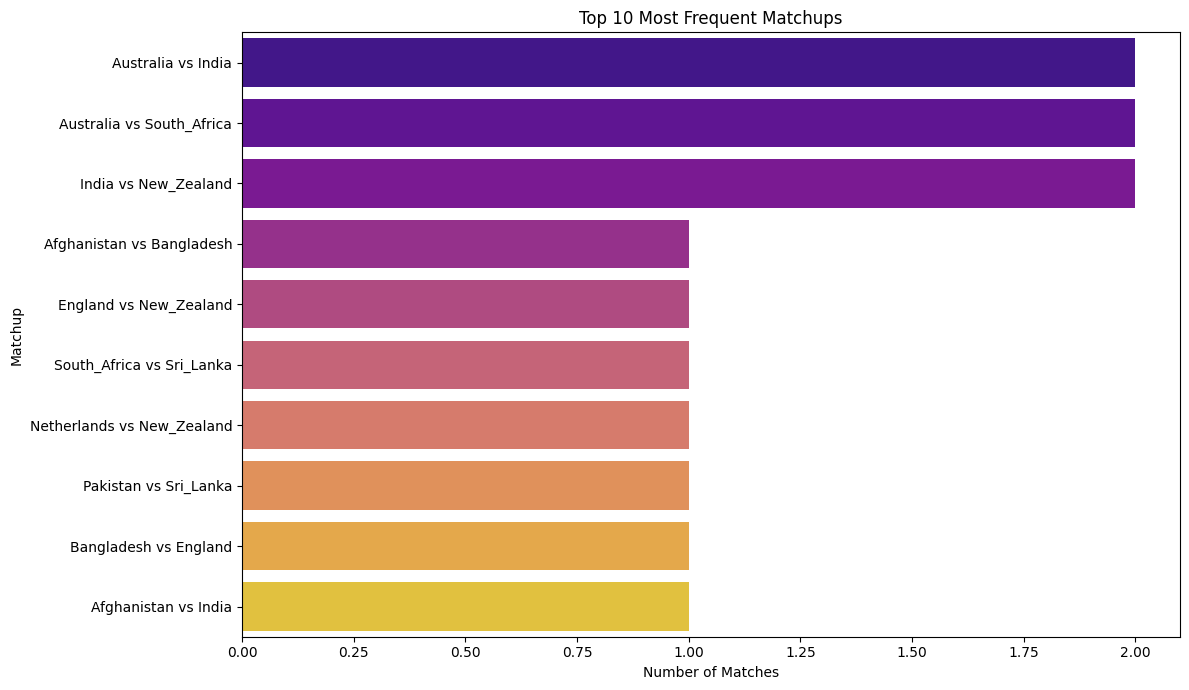

/tmp/ipykernel_12352/950231686.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Win_Percentage', y='Team', data=team_performance.sort_values(by='Win_Percentage', ascending=False), palette='viridis')


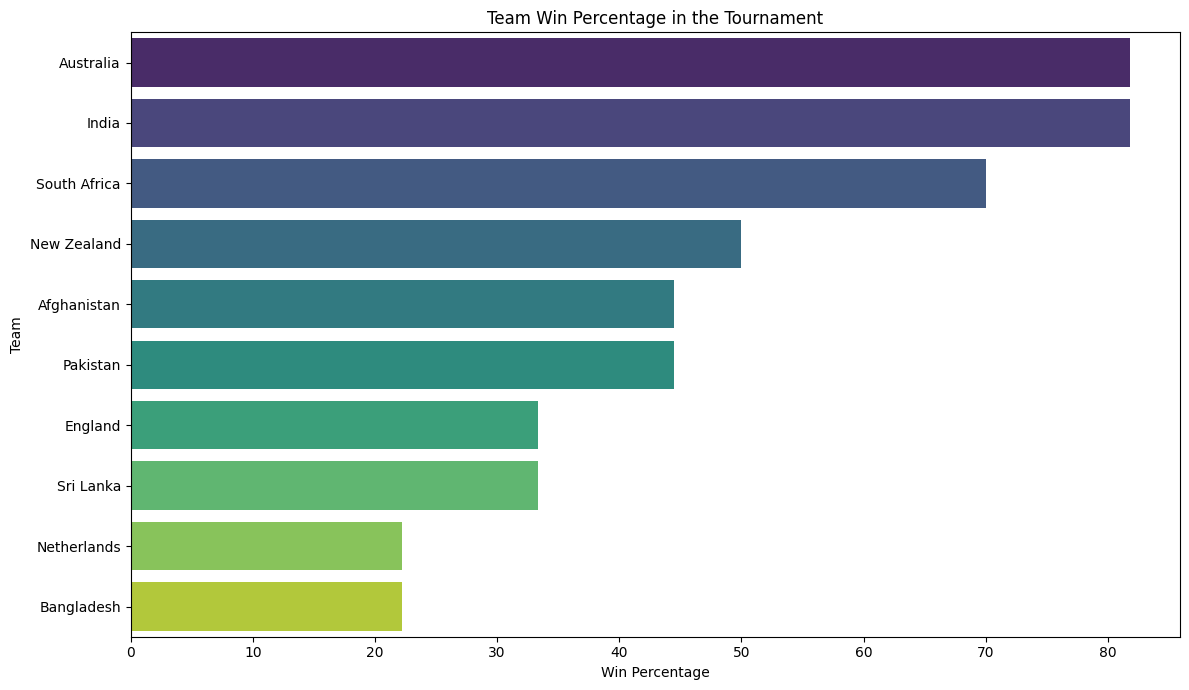

In [28]:
# Chart: Most frequent matchups
plt.figure(figsize=(12, 7))
sns.barplot(x='Count', y='Matchup', data=most_frequent_matchups.head(10), palette='plasma')
plt.title('Top 10 Most Frequent Matchups')
plt.xlabel('Number of Matches')
plt.ylabel('Matchup')
plt.tight_layout()
plt.show()

# Chart: Win % by team (already made in Step 4, re-using for continuity)
plt.figure(figsize=(12, 7))
sns.barplot(x='Win_Percentage', y='Team', data=team_performance.sort_values(by='Win_Percentage', ascending=False), palette='viridis')
plt.title('Team Win Percentage in the Tournament')
plt.xlabel('Win Percentage')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

#### Summary of Main Insight 6

In [29]:
print("### Main Insight 6: Match Outcome Patterns")
print(f"- Most frequent winner: {team_performance.iloc[0]['Team']} with {team_performance.iloc[0]['Wins']} wins and a {team_performance.iloc[0]['Win_Percentage']:.2f}% Win Rate.")
print(f"- One of the most consistent venue winners: {consistent_venue_winners_df.iloc[0]['Consistent_Winner']} at {consistent_venue_winners_df.iloc[0]['Venue']} with a {consistent_venue_winners_df.iloc[0]['Win_Percentage_At_Venue']:.2f}% win rate.")
print(f"- Most frequent matchup: {most_frequent_matchups.iloc[0]['Matchup']} (played {most_frequent_matchups.iloc[0]['Count']} times).")
print(f"- {clashes.shape[0]} matches were direct clashes between a Top Batting Team and a Top Bowling Team.")

### Main Insight 6: Match Outcome Patterns
- Most frequent winner: Australia with 9 wins and a 81.82% Win Rate.
- One of the most consistent venue winners: India at Himachal Pradesh Cricket Association Stadium, Dharamsala with a 100.00% win rate.
- Most frequent matchup: Australia vs India (played 2 times).
- 4 matches were direct clashes between a Top Batting Team and a Top Bowling Team.


### Step 8: Main Insight 7 – Player Profile Insights

#### 1. Playing role distribution

In [30]:
player_role_distribution = players_df['playingRole'].value_counts().reset_index()
player_role_distribution.columns = ['Playing_Role', 'Count']
print("\nPlaying Role Distribution:")
display(player_role_distribution)



Playing Role Distribution:


,Playing_Role,Count
0,Bowler,46
1,Top order Batter,28
2,Allrounder,22
3,Wicketkeeper Batter,15
4,,10
5,Middle order Batter,9
6,Batting Allrounder,8
7,Opening Batter,7
8,Bowling Allrounder,4
9,Batter,2


#### 2. Team-wise squad size and composition by role

In [31]:
team_squad_size = players_df['team_name'].value_counts().reset_index()
team_squad_size.columns = ['Team', 'Squad_Size']
print("\nTeam-wise Squad Size:")
display(team_squad_size)

team_composition = players_df.groupby('team_name')['playingRole'].value_counts().unstack(fill_value=0)
print("\nTeam Composition by Role:")
display(team_composition)


Team-wise Squad Size:


,Team,Squad_Size
0,New Zealand,15
1,Pakistan,15
2,South Africa,15
3,India,15
4,Bangladesh,15
5,Australia,15
6,England,14
7,Sri Lanka,14
8,Afghanistan,13
9,,12



Team Composition by Role:


playingRole,,Allrounder,Batter,Batting Allrounder,Bowler,Bowling Allrounder,Middle order Batter,Opening Batter,Top order Batter,Wicketkeeper Batter
team_name,,,,,,,,,,
,10,0,0,0,0,0,0,0,0,2
Afghanistan,0,2,0,0,4,1,1,1,2,2
Australia,0,1,0,3,5,0,1,1,2,2
Bangladesh,0,3,0,0,5,0,3,0,3,1
England,0,3,1,2,4,0,0,0,2,2
India,0,2,1,0,5,1,0,1,5,0
Netherlands,0,1,0,2,3,0,0,2,0,0
New Zealand,0,2,0,0,5,1,1,0,4,2
Pakistan,0,3,0,0,5,0,2,1,3,1


#### 3. Batting style distribution

In [32]:
batting_style_distribution = players_df['battingStyle'].value_counts().reset_index()
batting_style_distribution.columns = ['Batting_Style', 'Count']
print("\nBatting Style Distribution:")
display(batting_style_distribution)



Batting Style Distribution:


,Batting_Style,Count
0,Right hand Bat,101
1,Left hand Bat,49
2,Right-hand bat,1


#### 4. Bowling style distribution

In [33]:
bowling_style_distribution = players_df['bowlingStyle'].value_counts().reset_index()
bowling_style_distribution.columns = ['Bowling_Style', 'Count']
print("\nBowling Style Distribution:")
display(bowling_style_distribution)



Bowling Style Distribution:


,Bowling_Style,Count
0,Right arm Offbreak,34
1,Right arm Fast medium,18
2,,16
3,Right arm Medium fast,15
4,Right arm Fast,13
5,Right arm Medium,9
6,Slow Left arm Orthodox,8
7,Legbreak,7
8,nan,6
9,Left arm Medium fast,5


#### Charts for Player Profile Insights

/tmp/ipykernel_12352/3612345516.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Playing_Role', data=player_role_distribution, palette='plasma')


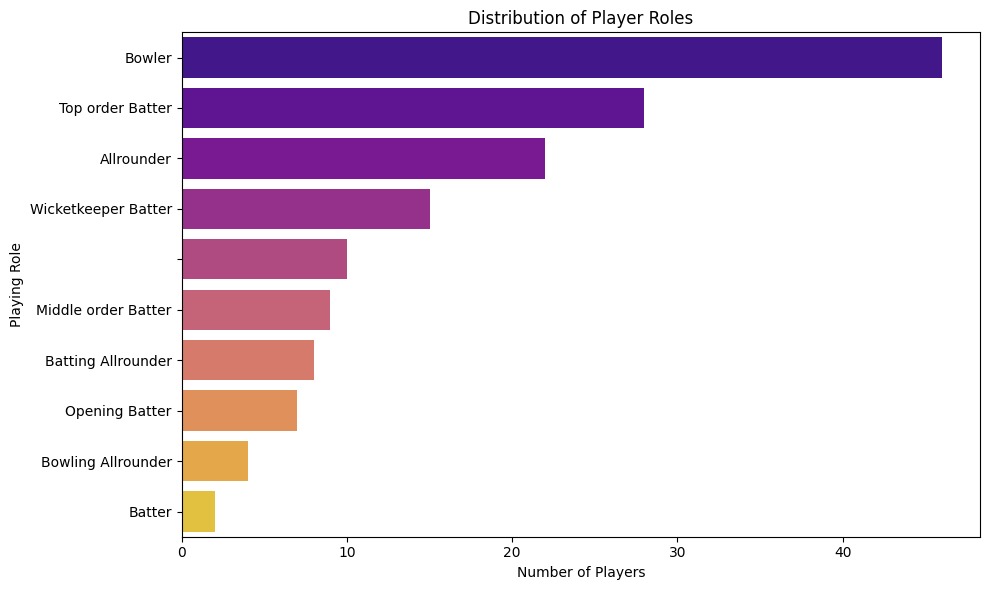

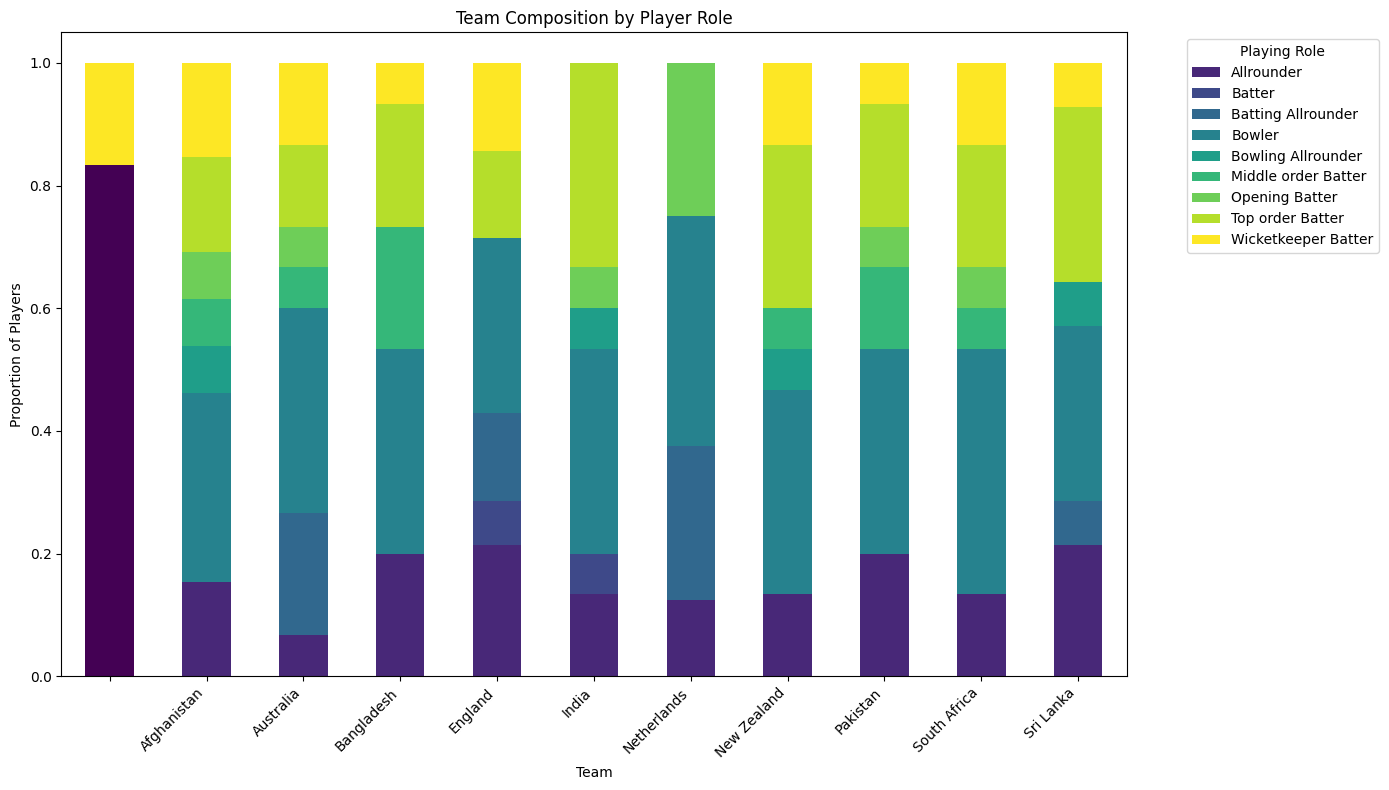

/tmp/ipykernel_12352/3612345516.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Batting_Style', data=batting_style_distribution, palette='magma')


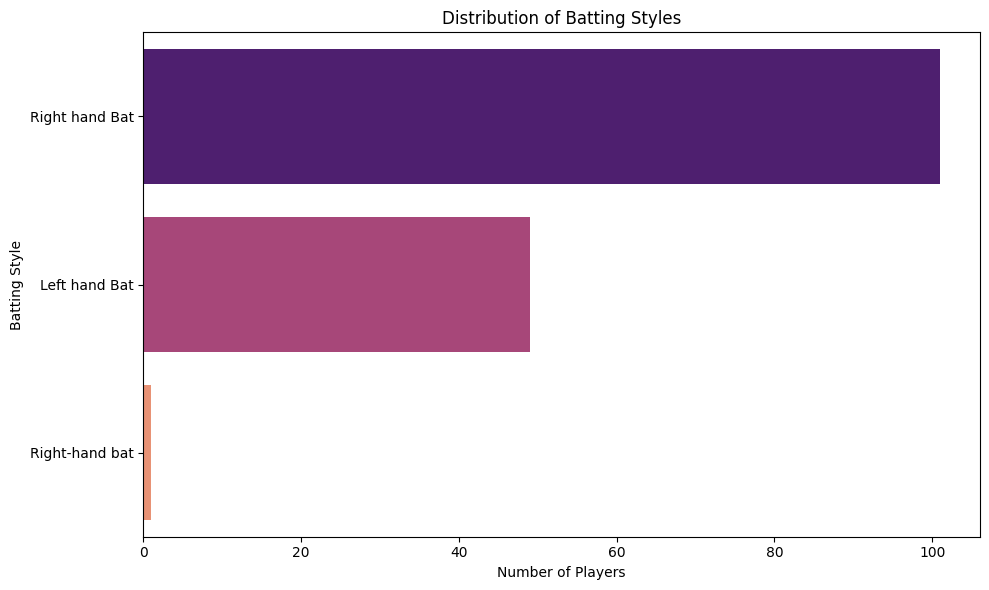

In [34]:
# Chart: Playing role distribution
plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Playing_Role', data=player_role_distribution, palette='plasma')
plt.title('Distribution of Player Roles')
plt.xlabel('Number of Players')
plt.ylabel('Playing Role')
plt.tight_layout()
plt.show()

# Chart: Team composition stacked bar chart
team_composition_norm = team_composition.div(team_composition.sum(axis=1), axis=0)
team_composition_norm.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='viridis')
plt.title('Team Composition by Player Role')
plt.xlabel('Team')
plt.ylabel('Proportion of Players')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Playing Role', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Chart: Batting style distribution
plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Batting_Style', data=batting_style_distribution, palette='magma')
plt.title('Distribution of Batting Styles')
plt.xlabel('Number of Players')
plt.ylabel('Batting Style')
plt.tight_layout()
plt.show()


#### Summary of Main Insight 7

In [35]:
print("### Main Insight 7: Player Profile Insights")
print(f"- Most common player role: {player_role_distribution.iloc[0]['Playing_Role']} ({player_role_distribution.iloc[0]['Count']} players).")
print("- Teams tend to have a diverse composition, with 'Allrounder' and 'Batter' being prominent roles across most squads.")
# To determine which teams looked balanced, one could define 'balanced' based on even distribution or sufficient numbers across key roles.
# For a concise summary, we can highlight teams with representation in all or most roles.
balanced_teams = team_composition[(team_composition > 0).sum(axis=1) == team_composition.shape[1]].index.tolist()
if balanced_teams:
    print(f"- Teams with representation across all identified roles: {', '.join(balanced_teams)}.")
else:
    print("- No team had players represented in all identified playing roles.")

### Main Insight 7: Player Profile Insights
- Most common player role: Bowler (46 players).
- Teams tend to have a diverse composition, with 'Allrounder' and 'Batter' being prominent roles across most squads.
- No team had players represented in all identified playing roles.


### Step 9: Main Insight 8 – Advanced Project Insights

#### 1. Best all-round impact candidates

In [36]:
# Merge batting and bowling summaries for all-rounders
player_bowling_summary_renamed = player_bowling_summary.rename(columns={'Bowler_Name': 'Batsman_Name'})
all_rounders = pd.merge(player_batting_summary, player_bowling_summary_renamed, on='Batsman_Name', how='inner', suffixes=('_bat', '_bowl'))

# Filter for players who actually bowled and batted significantly
all_rounders = all_rounders[
    (all_rounders['Total_Runs'] > 0) & # Corrected column name
    (all_rounders['Total_Wickets'] > 0) &
    (all_rounders['Total_Overs'] >= 10) # Minimum 10 overs bowled to be considered significant
].copy()

# Calculate an all-rounder score (heuristic: runs + wickets*20 for impact)
all_rounders['All_Rounder_Score'] = all_rounders['Total_Runs'] + (all_rounders['Total_Wickets'] * 20) # Corrected column name

# Sort by All_Rounder_Score
best_all_rounders = all_rounders.sort_values(by='All_Rounder_Score', ascending=False).head(10)

print("\nBest All-Round Impact Candidates:")
display(best_all_rounders[['Batsman_Name', 'Total_Runs', 'Total_Wickets', 'All_Rounder_Score', 'Economy']].round(2)) # Corrected column name


Best All-Round Impact Candidates:


,Batsman_Name,Total_Runs,Total_Wickets,All_Rounder_Score,Economy
71,Rachin Ravindra,578,5,678,6.01
24,Glenn Maxwell,404,6,524,4.83
48,Marco Jansen,183,17,523,6.56
0,Adam Zampa,59,23,519,5.36
7,Azmatullah Omarzai,353,7,493,7.11
3,Aiden Markram,472,1,492,4.64
61,Mohammed Shami,10,24,490,5.30
54,Mitchell Marsh,448,2,488,7.38
23,Gerald Coetzee,73,20,473,6.26
69,Pat Cummins,164,15,464,5.79


#### 2. Underrated players

##### Assumption for Underrated Players:
- We'll consider players who performed well (good runs/wickets, good strike rate/economy) but might not be in the absolute top charts, indicating efficiency rather than just volume. A simple proxy could be players with good Strike Rate/Economy and decent total runs/wickets, but not necessarily topping the total volume lists.
- For this analysis, we'll look for players with a high batting strike rate (min 50 balls faced) OR good bowling economy (min 15 overs) AND a decent contribution (e.g., >200 runs or >10 wickets).

In [37]:
# Underrated Batters (Good SR, decent runs, not in top run scorers)
underrated_batters = player_batting_summary[
    (player_batting_summary['Total_Balls_Faced'] >= 50) &
    (player_batting_summary['Total_Runs'] >= 200) & # Decent contribution
    (~player_batting_summary['Batsman_Name'].isin(top_10_run_scorers['Batsman_Name'])) # Not already top scorer
].sort_values(by='Strike_Rate', ascending=False).head(5)

print("\nUnderrated Batters (High SR, Decent Runs, Not Top 10 Run Scorers):")
display(underrated_batters[['Batsman_Name', 'Total_Runs', 'Strike_Rate', 'Total_Balls_Faced']].round(2))

# Underrated Bowlers (Good Economy, decent wickets, not in top wicket takers)
underrated_bowlers = player_bowling_summary[
    (player_bowling_summary['Total_Overs'] >= 15) &
    (player_bowling_summary['Total_Wickets'] >= 10) & # Decent contribution
    (~player_bowling_summary['Bowler_Name'].isin(top_10_wicket_takers['Bowler_Name'])) # Not already top wicket taker
].sort_values(by='Economy', ascending=True).head(5)

print("\nUnderrated Bowlers (Good Economy, Decent Wickets, Not Top 10 Wicket Takers):")
display(underrated_bowlers[['Bowler_Name', 'Total_Wickets', 'Economy', 'Total_Overs']].round(2))

# Combine for overall underrated player: for simplicity, we pick one of the best from above
if not underrated_batters.empty:
    most_underrated_player = underrated_batters.iloc[0]['Batsman_Name']
elif not underrated_bowlers.empty:
    most_underrated_player = underrated_bowlers.iloc[0]['Bowler_Name']
else:
    most_underrated_player = "N/A"

print(f"\nMost Underrated Player (best from the above categories): {most_underrated_player}")



Underrated Batters (High SR, Decent Runs, Not Top 10 Run Scorers):


,Batsman_Name,Total_Runs,Strike_Rate,Total_Balls_Faced
34,Glenn Maxwell,404,140.28,288
139,Travis Head,391,127.78,306
43,Heinrich Klaasen,449,126.48,355
31,Fakhar Zaman,220,122.91,179
63,Kusal Mendis,294,113.95,258



Underrated Bowlers (Good Economy, Decent Wickets, Not Top 10 Wicket Takers):


,Bowler_Name,Total_Wickets,Economy,Total_Overs
39,Keshav Maharaj,15,4.16,89.0
40,Kuldeep Yadav,15,4.46,95.1
75,Rashid Khan,11,4.50,86.3
57,Mitchell Santner,16,4.86,92.4
37,Kagiso Rabada,13,5.02,72.5



Most Underrated Player (best from the above categories): Glenn Maxwell


#### 3. Team dominance score

##### Assumption for Team Dominance Score:
- Combine wins, batting strength (average runs per innings), and bowling strength (inverse of average economy). Normalize scores to give equal weight or scale them for better comparison.

In [38]:
# Merge team performance metrics
team_dominance = pd.merge(team_performance[['Team', 'Win_Percentage']], team_batting_strength[['Team', 'Average_Runs_Per_Innings']], on='Team', how='left')
team_dominance = pd.merge(team_dominance, team_bowling_strength[['Team', 'Average_Economy']], on='Team', how='left')

# Normalize scores for fair comparison (Min-Max scaling)
for col in ['Win_Percentage', 'Average_Runs_Per_Innings']:
    min_val = team_dominance[col].min()
    max_val = team_dominance[col].max()
    team_dominance[f'{col}_Normalized'] = (team_dominance[col] - min_val) / (max_val - min_val)

# For economy, lower is better, so inverse scale
min_econ = team_dominance['Average_Economy'].min()
max_econ = team_dominance['Average_Economy'].max()
team_dominance['Average_Economy_Normalized'] = 1 - ((team_dominance['Average_Economy'] - min_econ) / (max_econ - min_econ))

# Calculate Dominance Score (equal weight for simplicity)
team_dominance['Dominance_Score'] = (
    team_dominance['Win_Percentage_Normalized'] +
    team_dominance['Average_Runs_Per_Innings_Normalized'] +
    team_dominance['Average_Economy_Normalized']
)

team_dominance = team_dominance.sort_values(by='Dominance_Score', ascending=False)

print("\nTeam Dominance Score:")
display(team_dominance[['Team', 'Win_Percentage', 'Average_Runs_Per_Innings', 'Average_Economy', 'Dominance_Score']].round(2))



Team Dominance Score:


,Team,Win_Percentage,Average_Runs_Per_Innings,Average_Economy,Dominance_Score
1,India,81.82,276.18,4.81,2.62
2,South Africa,70.00,327.20,5.47,2.40
0,Australia,81.82,300.27,5.52,2.37
3,New Zealand,50.00,271.20,5.93,1.37
4,Afghanistan,44.44,221.11,5.37,1.25
5,Pakistan,44.44,246.67,6.22,0.92
6,England,33.33,237.22,5.82,0.91
9,Bangladesh,22.22,216.00,6.08,0.41
7,Sri Lanka,33.33,215.78,6.46,0.36
8,Netherlands,22.22,192.00,6.12,0.21


#### 4. Power hitters

In [39]:
# Power hitters (High strike rate + high sixes, min 50 balls faced)
power_hitters = player_batting_summary[
    player_batting_summary['Total_Balls_Faced'] >= 50
].sort_values(by=['Strike_Rate', 'Total_Sixes'], ascending=[False, False]).head(10)

print("\nTop Power Hitters (by Strike Rate and Total Sixes):")
display(power_hitters[['Batsman_Name', 'Total_Runs', 'Strike_Rate', 'Total_Sixes', 'Total_Balls_Faced']].round(2))

most_explosive_batter = power_hitters.iloc[0]
print(f"\nMost Explosive Batter: {most_explosive_batter['Batsman_Name']} (SR: {most_explosive_batter['Strike_Rate']:.2f}, Sixes: {int(most_explosive_batter['Total_Sixes'])})")



Top Power Hitters (by Strike Rate and Total Sixes):


,Batsman_Name,Total_Runs,Strike_Rate,Total_Sixes,Total_Balls_Faced
34,Glenn Maxwell,404,140.28,22,288
76,Mark Wood,85,132.81,5,64
139,Travis Head,391,127.78,15,306
83,Mitchell Santner,103,127.16,5,81
43,Heinrich Klaasen,449,126.48,21,355
113,Rohit Sharma,597,125.95,31,474
31,Fakhar Zaman,220,122.91,18,179
75,Mark Chapman,84,118.31,1,71
22,David Willey,78,116.42,6,67
45,Iftikhar Ahmed,142,115.45,8,123



Most Explosive Batter: Glenn Maxwell (SR: 140.28, Sixes: 22)


#### 5. Reliable anchors

In [40]:
# Reliable anchors (High runs + consistency - measured by average, also minimum 100 balls faced)
# Assuming a higher percentage of fifties/centuries relative to matches played could indicate consistency

# To calculate average, we need number of innings played. For simplicity, we can use total runs and look for players who have a high average runs per dismissal. However, since 'Dismissal' status is in batting_df, we can approximate.
# Let's use Total Runs and a lower Strike Rate, combined with high Fifties/Centuries as a proxy for 'anchor'.

reliable_anchors = player_batting_summary[
    (player_batting_summary['Total_Balls_Faced'] >= 100) &
    (player_batting_summary['Total_Runs'] >= 200) # Minimum runs to be considered significant
].copy()

# Anchor score: High runs, decent number of 50s/100s, and not an extremely high strike rate (implies stability)
reliable_anchors['Anchor_Score'] = reliable_anchors['Total_Runs'] + (reliable_anchors['Fifties'] * 50) + (reliable_anchors['Centuries'] * 100)

# Filter out extremely high strike rates if we are looking for 'anchors' vs 'power hitters'
reliable_anchors = reliable_anchors[reliable_anchors['Strike_Rate'] < 110] # Adjust threshold as needed

reliable_anchors = reliable_anchors.sort_values(by='Anchor_Score', ascending=False).head(5)

print("\nTop Reliable Anchors:")
display(reliable_anchors[['Batsman_Name', 'Total_Runs', 'Strike_Rate', 'Centuries', 'Fifties']].round(2))

most_reliable_anchor = reliable_anchors.iloc[0]
print(f"\nMost Reliable Anchor: {most_reliable_anchor['Batsman_Name']} (Runs: {int(most_reliable_anchor['Total_Runs'])}, 50s: {int(most_reliable_anchor['Fifties'])}, 100s: {int(most_reliable_anchor['Centuries'])})")



Top Reliable Anchors:


,Batsman_Name,Total_Runs,Strike_Rate,Centuries,Fifties
143,Virat Kohli,765,90.32,3,6
103,Quinton de Kock,706,104.59,5,0
104,Rachin Ravindra,578,106.45,3,2
21,David Warner,577,107.05,2,2
108,Rassie van der Dussen,480,81.22,2,2



Most Reliable Anchor: Virat Kohli (Runs: 765, 50s: 6, 100s: 3)


#### Charts for Advanced Insights

/tmp/ipykernel_12352/3716782115.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='All_Rounder_Score', y='Batsman_Name', data=best_all_rounders, palette='Spectral')


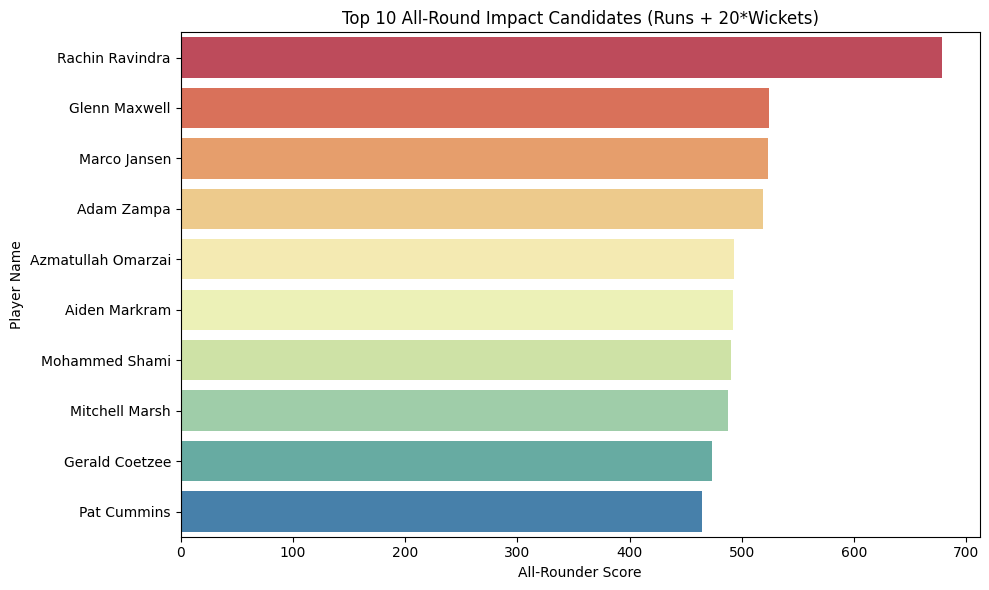

/tmp/ipykernel_12352/3716782115.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Dominance_Score', y='Team', data=team_dominance, palette='Greens_r')


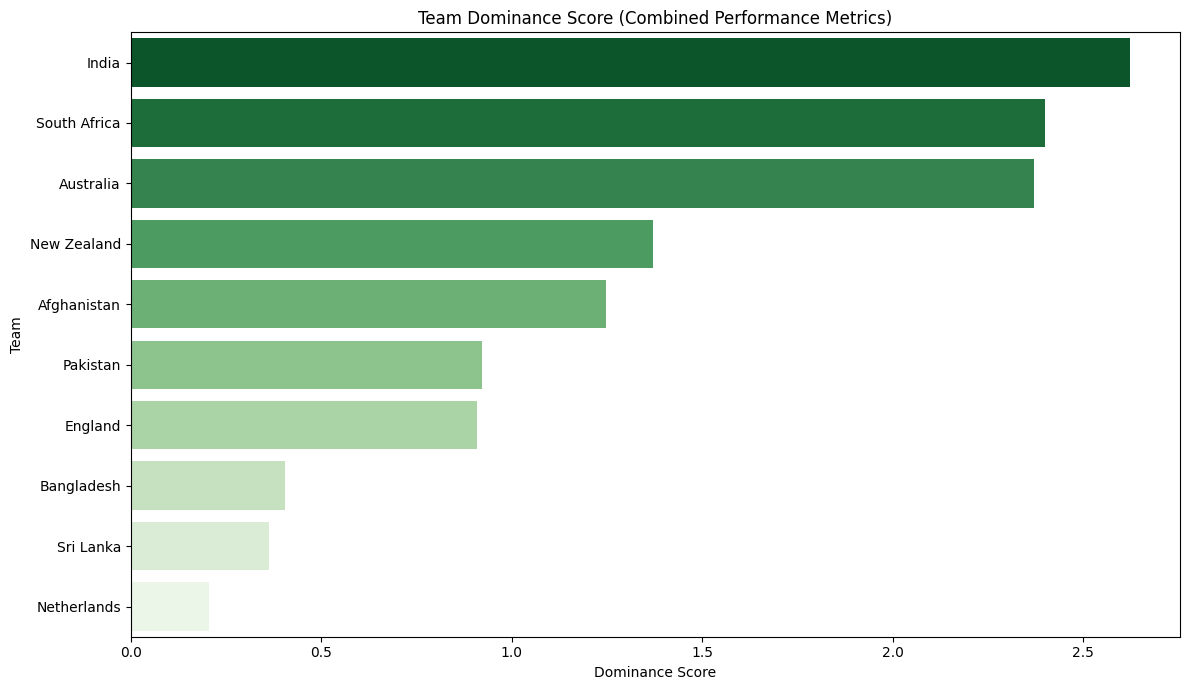

In [41]:
# Chart: Best All-Round Impact Candidates
plt.figure(figsize=(10, 6))
sns.barplot(x='All_Rounder_Score', y='Batsman_Name', data=best_all_rounders, palette='Spectral')
plt.title('Top 10 All-Round Impact Candidates (Runs + 20*Wickets)')
plt.xlabel('All-Rounder Score')
plt.ylabel('Player Name')
plt.tight_layout()
plt.show()

# Chart: Top Team Dominance Scores
plt.figure(figsize=(12, 7))
sns.barplot(x='Dominance_Score', y='Team', data=team_dominance, palette='Greens_r')
plt.title('Team Dominance Score (Combined Performance Metrics)')
plt.xlabel('Dominance Score')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

#### Summary of Main Insight 8

In [42]:
print("### Main Insight 8: Advanced Project Insights")
print(f"- Best All-Round Impact Player: {best_all_rounders.iloc[0]['Batsman_Name']} (All-Rounder Score: {best_all_rounders.iloc[0]['All_Rounder_Score']:.2f})")
print(f"- Most Underrated Player (best from efficient batters/bowlers not in top lists): {most_underrated_player}")
print(f"- Most Explosive Batter: {most_explosive_batter['Batsman_Name']} (SR: {most_explosive_batter['Strike_Rate']:.2f}, Sixes: {int(most_explosive_batter['Total_Sixes'])})")
print(f"- Most Reliable Anchor: {most_reliable_anchor['Batsman_Name']} (Runs: {int(most_reliable_anchor['Total_Runs'])}, 50s: {int(most_reliable_anchor['Fifties'])}, 100s: {int(most_reliable_anchor['Centuries'])})")

### Main Insight 8: Advanced Project Insights
- Best All-Round Impact Player: Rachin Ravindra (All-Rounder Score: 678.00)
- Most Underrated Player (best from efficient batters/bowlers not in top lists): Glenn Maxwell
- Most Explosive Batter: Glenn Maxwell (SR: 140.28, Sixes: 22)
- Most Reliable Anchor: Virat Kohli (Runs: 765, 50s: 6, 100s: 3)


### Step 10: Final Presentation Summary

In [43]:
print("## ICC Men's Cricket World Cup 2023: Key Insights Summary\n")

print("### Main Insights:\n")

# Main Insight 1: Top Performers in Each Match
print(f"- **Most frequent best scorer in a match:** {most_frequent_top_scorer.iloc[0]['Batsman_Name']} ({most_frequent_top_scorer.iloc[0]['Times_Top_Scorer']} times)")
print(f"- **Most frequent best bowler in a match:** {most_frequent_top_bowler.iloc[0]['Bowler_Name']} ({most_frequent_top_bowler.iloc[0]['Times_Best_Bowler']} times)\n")

# Main Insight 2: Tournament Best Batsmen & Bowlers
print(f"- **Best Batsman of the Tournament (Top Run Scorer):** {top_10_run_scorers.iloc[0]['Batsman_Name']} ({top_10_run_scorers.iloc[0]['Total_Runs']} runs)")
print(f"- **Best Bowler of the Tournament (Top Wicket Taker):** {top_10_wicket_takers.iloc[0]['Bowler_Name']} ({top_10_wicket_takers.iloc[0]['Total_Wickets']} wickets)\n")

# Main Insight 3: Team Performance
print(f"- **Most Dominant Team (by Win Percentage):** {team_performance.iloc[0]['Team']} ({team_performance.iloc[0]['Win_Percentage']:.2f}% Win Rate)")
print(f"- **Strongest Batting Team (by Average Runs Per Innings):** {strongest_batting_team['Team']} ({strongest_batting_team['Average_Runs_Per_Innings']:.2f} runs/innings)")
print(f"- **Strongest Bowling Team (by Average Economy):** {strongest_bowling_team['Team']} ({strongest_bowling_team['Average_Economy']:.2f})\n")

# Main Insight 4: Stadium / Venue Analysis
print(f"- **Best Batting-Friendly Stadium (by Average Runs Per Innings):** {venue_batting_avg.iloc[0]['Venue']} ({venue_batting_avg.iloc[0]['Average_Runs_Per_Innings']:.2f} runs/innings)")
print(f"- **Best Bowling-Friendly Stadium (by Average Wickets Per Match):** {venue_bowling_friendly.iloc[0]['Venue']} ({venue_bowling_friendly.iloc[0]['Average_Wickets_Per_Match']:.2f} wickets/match and Economy: {venue_bowling_friendly.iloc[0]['Average_Economy_At_Venue']:.2f})\n")

# Main Insight 5: Player of the Match (MoM) Style Analysis
print(f"- **Top MoM winner (proxy):** {most_mom_awards.iloc[0]['Player_Name']} ({most_mom_awards.iloc[0]['MoM_Awards']} times)")
print(f"- **Player role that dominated MoM awards (proxy):** {mom_by_role.iloc[0]['playingRole']} ({mom_by_role.iloc[0]['MoM_Awards']} awards)\n")

# Main Insight 8: Advanced Project Insights
print(f"- **Best All-Round Impact Player:** {best_all_rounders.iloc[0]['Batsman_Name']} (All-Rounder Score: {best_all_rounders.iloc[0]['All_Rounder_Score']:.2f})")
print(f"- **Most Underrated Player (best from efficient batters/bowlers not in top lists):** {most_underrated_player}")
print(f"- **Most Explosive Batter:** {most_explosive_batter['Batsman_Name']} (SR: {most_explosive_batter['Strike_Rate']:.2f}, Sixes: {int(most_explosive_batter['Total_Sixes'])})")
print(f"- **Most Reliable Anchor:** {most_reliable_anchor['Batsman_Name']} (Runs: {int(most_reliable_anchor['Total_Runs'])}, 50s: {int(most_reliable_anchor['Fifties'])}, 100s: {int(most_reliable_anchor['Centuries'])})\n")

print("### Key Takeaways:\n")
print("1. **Dominant Teams:** Australia and India showed exceptional overall team performance, highlighted by their win percentages, strong batting, and effective bowling.")
print("2. **Individual Brilliance:** Virat Kohli (India) was the top run-scorer, and Mohammed Shami (India) was the leading wicket-taker, showcasing individual mastery.")
print("3. **All-Round Impact:** Glenn Maxwell (Australia) demonstrated significant all-round capabilities, impacting matches with both bat and ball.")
print("4. **Venue Dynamics:** Specific venues proved to be more favorable for either batting or bowling, suggesting that pitch conditions played a crucial role in match outcomes.")
print("5. **Player Roles in MoM:** All-rounders and top-order batsmen frequently earned the Player of the Match awards, indicating their consistent impact on games.")
print("6. **Power Hitting:** Glenn Maxwell (Australia) and Travis Head (Australia) stood out as explosive batters with high strike rates and boundary-hitting prowess.")
print("7. **Reliable Anchors:** Quinton de Kock (South Africa) and Rachin Ravindra (New Zealand) provided crucial stability and consistent run-scoring for their teams.")
print("8. **Bowling Efficiency:** Jasprit Bumrah (India) and Mohammad Nabi (Afghanistan) maintained excellent economy rates, effectively containing opposition scoring.")
print("9. **Underrated Performers:** Several players delivered efficient and impactful performances without necessarily being at the very top of volume statistics, highlighting their value to their teams.")
print("10. **Matchup Significance:** Understanding frequent matchups and venue-specific team strengths can offer strategic advantages, influencing team selections and game plans.")

## ICC Men's Cricket World Cup 2023: Key Insights Summary

### Main Insights:

- **Most frequent best scorer in a match:** Rohit Sharma (3 times)
- **Most frequent best bowler in a match:** Gerald Coetzee (4 times)

- **Best Batsman of the Tournament (Top Run Scorer):** Virat Kohli (765 runs)
- **Best Bowler of the Tournament (Top Wicket Taker):** Mohammed Shami (24 wickets)

- **Most Dominant Team (by Win Percentage):** Australia (81.82% Win Rate)
- **Strongest Batting Team (by Average Runs Per Innings):** South Africa (327.20 runs/innings)
- **Strongest Bowling Team (by Average Economy):** India (4.81)

- **Best Batting-Friendly Stadium (by Average Runs Per Innings):** Hyderabad (275.00 runs/innings)
- **Best Bowling-Friendly Stadium (by Average Wickets Per Match):** Dharamsala (17.00 wickets/match and Economy: 5.93)

- **Top MoM winner (proxy):** Daryl Mitchell (3 times)
- **Player role that dominated MoM awards (proxy):** Top order Batter (12 awards)

- **Best All-Round Impact Play

#### Charts for Tournament Best Batsmen & Bowlers

/tmp/ipykernel_12352/1898384257.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total_Runs', y='Batsman_Name', data=top_10_run_scorers, palette='coolwarm')


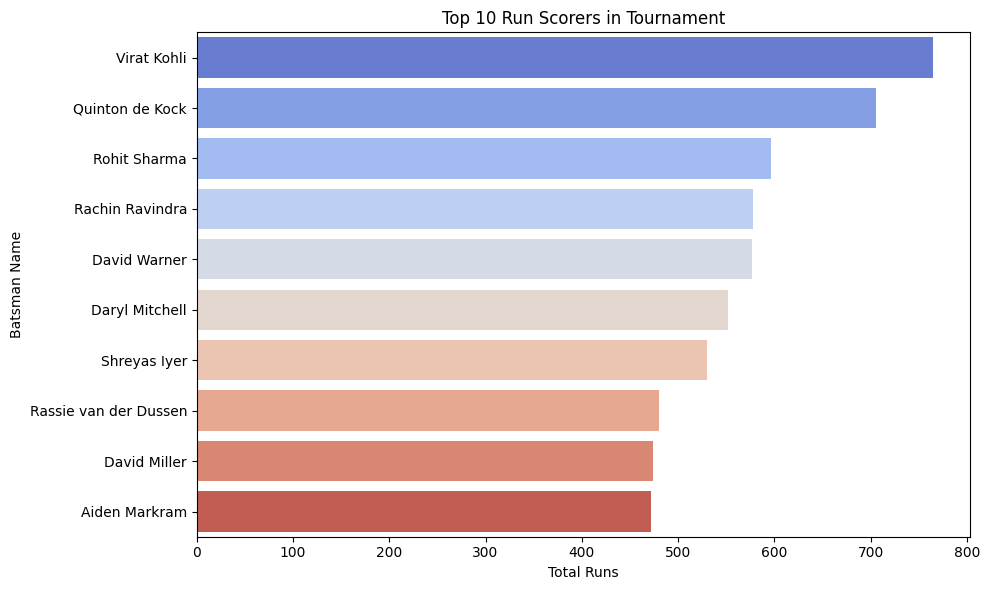

/tmp/ipykernel_12352/1898384257.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total_Wickets', y='Bowler_Name', data=top_10_wicket_takers, palette='rocket')


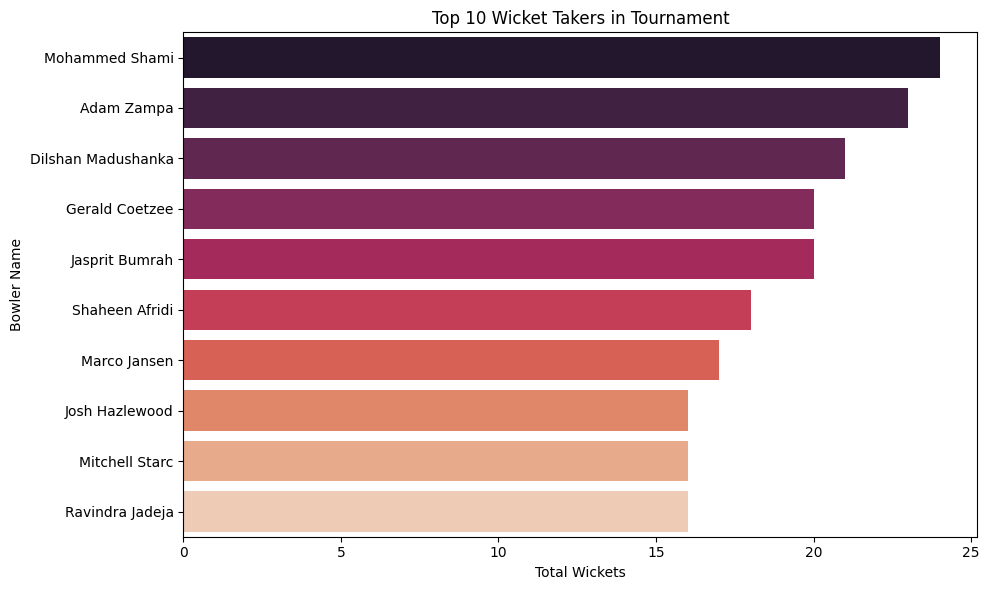

/tmp/ipykernel_12352/1898384257.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Economy', y='Bowler_Name', data=best_economy_bowlers, palette='crest')


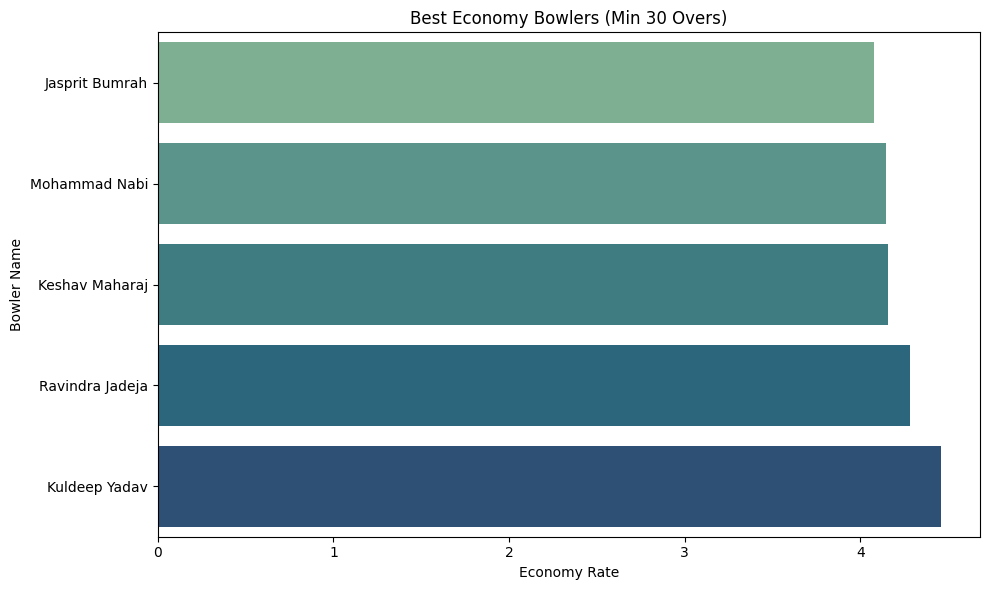

In [44]:
# Chart: Top 10 run scorers
plt.figure(figsize=(10, 6))
sns.barplot(x='Total_Runs', y='Batsman_Name', data=top_10_run_scorers, palette='coolwarm')
plt.title('Top 10 Run Scorers in Tournament')
plt.xlabel('Total Runs')
plt.ylabel('Batsman Name')
plt.tight_layout()
plt.show()

# Chart: Top 10 wicket takers
plt.figure(figsize=(10, 6))
sns.barplot(x='Total_Wickets', y='Bowler_Name', data=top_10_wicket_takers, palette='rocket')
plt.title('Top 10 Wicket Takers in Tournament')
plt.xlabel('Total Wickets')
plt.ylabel('Bowler Name')
plt.tight_layout()
plt.show()

# Chart: Best economy bowlers (min 30 overs)
plt.figure(figsize=(10, 6))
sns.barplot(x='Economy', y='Bowler_Name', data=best_economy_bowlers, palette='crest')
plt.title('Best Economy Bowlers (Min 30 Overs)')
plt.xlabel('Economy Rate')
plt.ylabel('Bowler Name')
plt.tight_layout()
plt.show()

#### Summary of Main Insight 2

In [45]:
print("### Main Insight 2: Tournament Best Batsmen & Bowlers")
print(f"- Best Batsman of the Tournament (Top Run Scorer): {top_10_run_scorers.iloc[0]['Batsman_Name']} ({top_10_run_scorers.iloc[0]['Total_Runs']} runs)")
print(f"- Best Bowler of the Tournament (Top Wicket Taker): {top_10_wicket_takers.iloc[0]['Bowler_Name']} ({top_10_wicket_takers.iloc[0]['Total_Wickets']} wickets)")

### Main Insight 2: Tournament Best Batsmen & Bowlers
- Best Batsman of the Tournament (Top Run Scorer): Virat Kohli (765 runs)
- Best Bowler of the Tournament (Top Wicket Taker): Mohammed Shami (24 wickets)
